In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report
from IPython.display import display, HTML
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error, auc, roc_curve, roc_auc_score
from decimal import Decimal
import geopandas as gpd
from shapely.geometry import Point
from scipy.interpolate import griddata
import rasterio
from rasterio.transform import from_origin
from sklearn.feature_selection import RFE
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import cross_val_score
from scipy import stats
from sklearn.feature_selection import f_regression


# Get multiple outputs in the same cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Ignore all warnings
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings(action='ignore', category=DeprecationWarning)
pd.set_option('display.max_columns', None)

## Data preparation

In [2]:
# Read in the data 
# We have two dataframes with same column but different data 
# I believe we should have one dataframe contain information about both dataframes (presence and absence)

# Here below we are reading the standardised dataframes
# presence_df = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/input_points_data/points_for_training/standardised_points_of_presence.csv', delimiter=';')
# absence_df = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/input_points_data/points_for_training/standardised_points_of_absence.csv', delimiter=';')

presence_df = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/input_points_data/points_for_training/non_standardised_points_of_presence.csv', delimiter=';')
absence_df = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/input_points_data/points_for_training/non_standardised_points_of_absence.csv', delimiter=';')

print("Presence info", presence_df.shape)
print("Absence info", absence_df.shape)

Presence info (46110, 22)
Absence info (46110, 22)


In [3]:
# Head for points of presence data
print("Points of presence")
presence_df.head()

# Head for points of absence data
print("Points of absence")
absence_df.head()

Points of presence


,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_albers_k30_wc,composite_temp_min_1000m_albers_k30_wc,composite_temp_max_1000m_albers_k30_wc,composite_rainfall_sum_1000m_albers_k30_wc,composite_gdd_grapes_1000m_albers_wc,composite_AETI_1000m_albers_wc,nitrogen_15_to_30cm_1000m_albers_wc,sand_15_to_30cm_1000m_albers_wc,soc_15_to_30cm_1000m_albers_wc,clay_content_15_to_30cm_1000m_albers_wc,soil_ph_15_to_30cm_1000m_albers_wc,silt_15_to_30cm_1000m_albers_wc
0,1,"19,552906066300000","-33,503039127100003","364,6927185","1410672,8750000","7,4395833","0,6732290","139,6055298","295133,6562500","0,0496216","16,5896759","10,0150051","23,9883308","202,1145935","2015,7783203","10743,0000000",127,653,182,226,69,121
1,2,"19,554065257300000","-33,502591599200002","439,9613037","1054039,6250000","7,4746490","25,4787025","152,9988403","295133,6562500","0,0496216","15,1528301","9,1955242","21,8192177","203,3436890","1668,1140137","10743,0000000",114,674,222,206,68,120
2,3,"19,553220609499999","-33,504088723999999","364,6927185","1410672,8750000","7,4395833","0,6732290","139,6055298","295133,6562500","0,0496216","16,5896759","10,0150051","23,9883308","202,1145935","2015,7783203","10743,0000000",123,711,208,188,68,101
3,4,"19,554527855100002","-33,504862308200003","364,6927185","1410672,8750000","7,4395833","0,6732290","139,6055298","295133,6562500","0,0496216","16,0067024","9,7035923","23,0723820","202,1145935","1869,2829590","10743,0000000",145,705,192,190,67,105
4,5,"19,553802071600000","-33,504471387300001","364,6927185","1410672,8750000","7,4395833","0,6732290","139,6055298","295133,6562500","0,0496216","16,0067024","9,7035923","23,0723820","202,1145935","1869,2829590","10743,0000000",145,705,192,190,67,105


Points of absence


,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_albers_k30_wc,composite_temp_min_1000m_albers_k30_wc,composite_temp_max_1000m_albers_k30_wc,composite_rainfall_sum_1000m_albers_k30_wc,composite_gdd_grapes_1000m_albers_wc,composite_AETI_1000m_albers_wc,nitrogen_15_to_30cm_1000m_albers_wc,sand_15_to_30cm_1000m_albers_wc,soc_15_to_30cm_1000m_albers_wc,clay_content_15_to_30cm_1000m_albers_wc,soil_ph_15_to_30cm_1000m_albers_wc,silt_15_to_30cm_1000m_albers_wc
0,1,"19,929761337216007","-34,669140494937835","17,7946796","1340292,2500000","11,6952467","0,3641540","89,0314331","27841,6406250","-0,0183372","18,1797295","13,7422514","24,0061131","238,3125916","2162,5483398","4199,3999023",92,591,158,242,70,167
1,2,"20,853933888937888","-33,715715851505308","473,5272522","1455557,0000000","6,6464567","1,4877694","26,6495094","224218,3281250","0,0539246","17,1766319","10,4418173","25,2588501","118,1889648","2210,9208984","1051,4000244",135,613,199,232,80,154
2,3,"19,913425410354478","-33,069432348823796","592,6149292","1469614,6250000","8,4387312","1,0113984","120,0747452","390013,8125000","-0,0926514","17,6662331","10,1715412","26,0350609","39,0995865","2358,2729492","1104,8000488",52,668,102,193,81,138
3,4,"20,004340442657337","-34,698642588284770","9,1548433","1327371,7500000","8,3771544","1,0544152","171,6720428","15904,3398438","-0,0000000","18,0210285","13,6643248","23,6577148","189,8173370","2126,8022461","4816,2001953",91,591,274,246,69,163
4,5,"19,366437462219153","-34,315189103893999","410,5380249","1188012,5000000","6,7542100","18,0802574","170,0503082","80579,9531250","0,3867798","15,6344204","11,2751560","21,4288502","485,2016602","1713,6835938","5110,0000000",92,600,192,264,63,136


In [4]:
# Check for Null values 
print("Null result for presence")
presence_df.isnull().sum()

print("Null results for absence")
absence_df.isnull().sum()

# Interesting with the standardised data there are no null values 
# PS standardised the data using fuzzy membership functions linear membership function 

Null result for presence


OID_                                              0
POINT_X                                           0
POINT_Y                                           0
sudem_1000m_albers_filled_wc                      0
sudem_1000m_albers_potential_solar_rad_wh2m_wc    0
sudem_1000m_albers_twi_d8_wc                      0
sudem_1000m_albers_slope_degree_wc                0
sudem_1000m_albers_aspect_wc                      0
sudem_1000m_albers_flow_network_wc                0
sudem_1000m_albers_curvature_wc                   0
composite_temp_mean_1000m_albers_k30_wc           0
composite_temp_min_1000m_albers_k30_wc            0
composite_temp_max_1000m_albers_k30_wc            0
composite_rainfall_sum_1000m_albers_k30_wc        0
composite_gdd_grapes_1000m_albers_wc              0
composite_AETI_1000m_albers_wc                    0
nitrogen_15_to_30cm_1000m_albers_wc               0
sand_15_to_30cm_1000m_albers_wc                   0
soc_15_to_30cm_1000m_albers_wc                    0
clay_content

Null results for absence


OID_                                              0
POINT_X                                           0
POINT_Y                                           0
sudem_1000m_albers_filled_wc                      0
sudem_1000m_albers_potential_solar_rad_wh2m_wc    0
sudem_1000m_albers_twi_d8_wc                      0
sudem_1000m_albers_slope_degree_wc                0
sudem_1000m_albers_aspect_wc                      0
sudem_1000m_albers_flow_network_wc                0
sudem_1000m_albers_curvature_wc                   0
composite_temp_mean_1000m_albers_k30_wc           0
composite_temp_min_1000m_albers_k30_wc            0
composite_temp_max_1000m_albers_k30_wc            0
composite_rainfall_sum_1000m_albers_k30_wc        0
composite_gdd_grapes_1000m_albers_wc              0
composite_AETI_1000m_albers_wc                    1
nitrogen_15_to_30cm_1000m_albers_wc               0
sand_15_to_30cm_1000m_albers_wc                   0
soc_15_to_30cm_1000m_albers_wc                    0
clay_content

In [5]:
# Adding suitability column to both df and assigning a value of 1 to where there vineyards and 0 where there are no vineyards

presence_df['suitability'] = 1  # Highly suitable (characteristics for suitable vineyards)
absence_df['suitability'] = 0  # Less suitable (characteristics for potential suitability/ non suitability)

# Checking size of the dataframes
print("Checking size of the dataframes")
presence_df['suitability'].value_counts()
absence_df['suitability'].value_counts()

Checking size of the dataframes


suitability
1    46110
Name: count, dtype: int64

suitability
0    46110
Name: count, dtype: int64

In [6]:
# Combine the datasets
# other combining functions include merge() join()
# combined_df = pd.concat([presence_df, absence_df], axis=0) (This concatinates my df as strings which resulted in some values being Nan, results in twice as many points)

# merge function combines the df using a common column and then renames columns that were same using x o y suffixes 
# results in 46110 points (original value)
# creates separate column called suitability_x and suitability_y 
# concatinating the df vertically and axis=0 adds rows, axis = 1 adds columns

combined_df = pd.concat([presence_df, absence_df], axis=0, ignore_index=True)

print("combined dataframe")
combined_df


combined dataframe


,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_albers_k30_wc,composite_temp_min_1000m_albers_k30_wc,composite_temp_max_1000m_albers_k30_wc,composite_rainfall_sum_1000m_albers_k30_wc,composite_gdd_grapes_1000m_albers_wc,composite_AETI_1000m_albers_wc,nitrogen_15_to_30cm_1000m_albers_wc,sand_15_to_30cm_1000m_albers_wc,soc_15_to_30cm_1000m_albers_wc,clay_content_15_to_30cm_1000m_albers_wc,soil_ph_15_to_30cm_1000m_albers_wc,silt_15_to_30cm_1000m_albers_wc,suitability
0,1,"19,552906066300000","-33,503039127100003","364,6927185","1410672,8750000","7,4395833","0,6732290","139,6055298","295133,6562500","0,0496216","16,5896759","10,0150051","23,9883308","202,1145935","2015,7783203","10743,0000000",127,653,182,226,69,121,1
1,2,"19,554065257300000","-33,502591599200002","439,9613037","1054039,6250000","7,4746490","25,4787025","152,9988403","295133,6562500","0,0496216","15,1528301","9,1955242","21,8192177","203,3436890","1668,1140137","10743,0000000",114,674,222,206,68,120,1
2,3,"19,553220609499999","-33,504088723999999","364,6927185","1410672,8750000","7,4395833","0,6732290","139,6055298","295133,6562500","0,0496216","16,5896759","10,0150051","23,9883308","202,1145935","2015,7783203","10743,0000000",123,711,208,188,68,101,1
3,4,"19,554527855100002","-33,504862308200003","364,6927185","1410672,8750000","7,4395833","0,6732290","139,6055298","295133,6562500","0,0496216","16,0067024","9,7035923","23,0723820","202,1145935","1869,2829590","10743,0000000",145,705,192,190,67,105,1
4,5,"19,553802071600000","-33,504471387300001","364,6927185","1410672,8750000","7,4395833","0,6732290","139,6055298","295133,6562500","0,0496216","16,0067024","9,7035923","23,0723820","202,1145935","1869,2829590","10743,0000000",145,705,192,190,67,105,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92215,46106,"22,319073904337245","-31,657236599489408","1490,0520020","1634508,5000000","6,9371290","2,2243729","234,1012726","170005,4687500","0,2257080","16,1176319","10,0076084","22,6117344","37,0005569","1970,2152100","1452,5999756",58,613,68,218,80,169,0
92216,46107,"23,756007858276064","-31,744018585988897","1255,3397217","1613245,7500000","7,3959880","0,7032246","23,3724918","426645,2812500","0,0275879","16,0509167","8,6489143","23,8269997","217,3677673","2037,2808838","2138,3999023",58,561,69,235,82,204,0
92217,46108,"23,495416236370261","-31,793901584990124","1161,9631348","1596783,8750000","7,7575145","1,2980939","168,7865906","412358,5000000","0,0905762","16,7605782","9,2522469","24,7201157","153,9411926","2193,7636719","1116,8000488",50,577,117,238,82,185,0
92218,46109,"22,474740777764737","-31,765556181672423","1549,8642578","1663428,3750000","7,5858736","1,7443620","139,9519348","487913,5937500","0,0007324","15,5835619","9,6879883","21,7396202","54,5152473","1826,6328125","1686,4000244",60,587,69,195,79,218,0


In [7]:
# Remove NDVI, ROADS and RIVERS from the combined dataframe
# NDVI might be leading to some bias in the model
# ROADS and RIVERS are not important for the model

# The points that are standardised do not have ndvi_wc, euclidean_distance_roads_1000m_albers_wc, euclidean_distance_rivers_1000m_albers_wc

# combined_df = combined_df.drop(['ndvi_wc', 'euclidean_distance_roads_1000m_albers_wc', 'euclidean_distance_rivers_1000m_albers_wc'], axis=1) 


In [8]:
# Data types of the columns before conversion
combined_df.dtypes

OID_                                               int64
POINT_X                                           object
POINT_Y                                           object
sudem_1000m_albers_filled_wc                      object
sudem_1000m_albers_potential_solar_rad_wh2m_wc    object
sudem_1000m_albers_twi_d8_wc                      object
sudem_1000m_albers_slope_degree_wc                object
sudem_1000m_albers_aspect_wc                      object
sudem_1000m_albers_flow_network_wc                object
sudem_1000m_albers_curvature_wc                   object
composite_temp_mean_1000m_albers_k30_wc           object
composite_temp_min_1000m_albers_k30_wc            object
composite_temp_max_1000m_albers_k30_wc            object
composite_rainfall_sum_1000m_albers_k30_wc        object
composite_gdd_grapes_1000m_albers_wc              object
composite_AETI_1000m_albers_wc                    object
nitrogen_15_to_30cm_1000m_albers_wc                int64
sand_15_to_30cm_1000m_albers_wc

In [9]:
# Remove commas from the values and convert to float/double
# removed the following columns from the list: 'ndvi_wc', 'euclidean_distance_roads_1000m_albers_wc', 'euclidean_distance_rivers_1000m_albers_wc'
def clean_and_convert(x):
    return x.str.replace(',', '.').astype('float')

# This is for the non-standardised data
columns_to_convert = ['POINT_X', 'POINT_Y', 'sudem_1000m_albers_filled_wc', 'sudem_1000m_albers_potential_solar_rad_wh2m_wc',
                        'sudem_1000m_albers_twi_d8_wc', 'sudem_1000m_albers_slope_degree_wc', 'sudem_1000m_albers_aspect_wc',
                        'sudem_1000m_albers_flow_network_wc', 'sudem_1000m_albers_curvature_wc',
                        'composite_temp_mean_1000m_albers_k30_wc', 'composite_temp_min_1000m_albers_k30_wc', 'composite_temp_max_1000m_albers_k30_wc',
                        'composite_rainfall_sum_1000m_albers_k30_wc', 'composite_gdd_grapes_1000m_albers_wc', 'composite_AETI_1000m_albers_wc'] 

# This is for the standardised data
# Note that the rainfall variable might be different from the non-standardised data (the other contains albers in the name and the other does not)
# columns_to_convert = ['POINT_X', 'POINT_Y', 'sudem_1000m_albers_filled_wc_fuzzy_linear', 'sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear',
#                         'sudem_1000m_albers_twi_d8_wc_fuzzy_linear', 'sudem_1000m_albers_slope_degree_wc_fuzzy_linear',
#                         'sudem_1000m_albers_aspect_wc_fuzzy_linear', 'sudem_1000m_albers_flow_network_wc_fuzzy_linear', 'sudem_1000m_albers_curvature_wc_fuzzy_linear',
#                         'composite_temp_mean_1000m_albers_k30_wc_fuzzy_linear', 'composite_temp_min_1000m_albers_k30_wc_fuzzy_linear', 'composite_temp_max_1000m_albers_k30_wc_fuzzy_linear',
#                         'composite_rainfall_sum_1000m_albers_k30_wc_fuzzy_linear', 'composite_gdd_grapes_1000m_albers_wc_fuzzy_linear', 'composite_AETI_1000m_albers_wc_fuzzy_linear',
#                         'nitrogen_15_to_30cm_1000m_albers_wc_fuzzy_linear', 'sand_15_to_30cm_1000m_albers_wc_fuzzy_linear', 'soc_15_to_30cm_1000m_albers_wc_fuzzy_linear',
#                         'clay_content_15_to_30cm_1000m_albers_wc_fuzzy_linear', 'soil_ph_15_to_30cm_1000m_albers_wc_fuzzy_linear', 'silt_15_to_30cm_1000m_albers_wc_fuzzy_linear']

for col in columns_to_convert:
    combined_df[col] = clean_and_convert(combined_df[col])

In [10]:
# Data types of the columns after conversion
combined_df.dtypes

OID_                                                int64
POINT_X                                           float64
POINT_Y                                           float64
sudem_1000m_albers_filled_wc                      float64
sudem_1000m_albers_potential_solar_rad_wh2m_wc    float64
sudem_1000m_albers_twi_d8_wc                      float64
sudem_1000m_albers_slope_degree_wc                float64
sudem_1000m_albers_aspect_wc                      float64
sudem_1000m_albers_flow_network_wc                float64
sudem_1000m_albers_curvature_wc                   float64
composite_temp_mean_1000m_albers_k30_wc           float64
composite_temp_min_1000m_albers_k30_wc            float64
composite_temp_max_1000m_albers_k30_wc            float64
composite_rainfall_sum_1000m_albers_k30_wc        float64
composite_gdd_grapes_1000m_albers_wc              float64
composite_AETI_1000m_albers_wc                    float64
nitrogen_15_to_30cm_1000m_albers_wc                 int64
sand_15_to_30c

In [11]:
# Describe the data and check for nulls again

combined_df.describe()
# combined_df.head(10)
combined_df['suitability'].value_counts()

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_albers_k30_wc,composite_temp_min_1000m_albers_k30_wc,composite_temp_max_1000m_albers_k30_wc,composite_rainfall_sum_1000m_albers_k30_wc,composite_gdd_grapes_1000m_albers_wc,composite_AETI_1000m_albers_wc,nitrogen_15_to_30cm_1000m_albers_wc,sand_15_to_30cm_1000m_albers_wc,soc_15_to_30cm_1000m_albers_wc,clay_content_15_to_30cm_1000m_albers_wc,soil_ph_15_to_30cm_1000m_albers_wc,silt_15_to_30cm_1000m_albers_wc,suitability
count,92220.000000,92220.000000,92220.000000,92220.000000,9.222000e+04,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92219.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000
mean,23055.500000,19.911518,-33.252359,409.132801,1.418926e+06,8.040928,5.734162,183.817519,195599.243954,0.001509,17.250063,11.404697,24.183576,227.125625,2148.651869,4781.319612,99.270082,670.344491,150.307732,187.299089,68.711885,121.407764,0.500000
std,13310.882622,1.435040,0.826937,362.738717,9.409715e+04,2.360408,7.226550,104.342359,119734.099093,0.249124,1.197797,1.241946,1.751265,176.942976,283.989250,2619.445363,35.508324,119.377081,61.969576,47.692830,11.875176,41.676145,0.500003
min,1.000000,17.842223,-34.791018,0.864634,4.766912e+05,2.493343,0.002707,-1.000000,718.994995,-4.407227,9.821478,4.953309,14.872516,19.354483,596.162903,14.400000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,11528.000000,18.855983,-33.834191,158.154922,1.377550e+06,6.706002,1.469463,91.273043,75319.808594,-0.071167,16.731258,10.695703,23.167980,92.741135,2007.081390,2594.399902,75.000000,632.000000,113.000000,161.000000,64.000000,93.000000,0.000000
50%,23055.500000,19.347553,-33.558733,256.835449,1.402788e+06,7.609663,2.904454,189.205994,209788.515625,-0.000000,17.390013,11.516291,24.486555,174.848434,2192.338257,4745.200195,99.000000,680.000000,143.000000,190.000000,69.000000,124.000000,0.500000
75%,34583.000000,20.660675,-32.815619,597.649704,1.463359e+06,8.672426,6.701010,272.238251,288067.625000,0.069733,17.994510,12.485985,25.327967,306.462341,2322.025635,6760.200195,122.000000,741.000000,182.000000,215.000000,76.000000,147.000000,1.000000
max,46110.000000,24.163170,-30.459279,2171.481445,1.873457e+06,27.933968,66.695923,359.998108,501860.468750,7.507690,19.873241,13.866605,28.325413,2164.634766,2857.601562,14092.200195,342.000000,893.000000,836.000000,343.000000,85.000000,377.000000,1.000000


suitability
1    46110
0    46110
Name: count, dtype: int64

In [12]:
# sort the dataframes by POINT_X and POINT_Y
combined_df = combined_df.sort_values(by=['POINT_X', 'POINT_Y'])

In [13]:
# Try to use interpolation to fill the null values after converting the columns to float
# Interpolation is done based on the surrounding values in the column
# add the columns that have null values to the list below

# No interpolation was needed for the standardised data since there were no null values

columns_to_interpolate = ['sudem_1000m_albers_curvature_wc', 'sudem_1000m_albers_flow_network_wc',
                        'composite_temp_mean_1000m_albers_k30_wc','composite_temp_min_1000m_albers_k30_wc',
                        'composite_temp_max_1000m_albers_k30_wc', 'composite_rainfall_sum_1000m_albers_k30_wc',
                        'composite_gdd_grapes_1000m_albers_wc', 'composite_AETI_1000m_albers_wc']


def interpolate_columns(df, columns):
    for col in columns:
        df[col].interpolate(method='linear', inplace=True)
    return df

interpolate_columns(combined_df, columns_to_interpolate)

# check again for nulls
combined_df.isnull().sum()

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_albers_k30_wc,composite_temp_min_1000m_albers_k30_wc,composite_temp_max_1000m_albers_k30_wc,composite_rainfall_sum_1000m_albers_k30_wc,composite_gdd_grapes_1000m_albers_wc,composite_AETI_1000m_albers_wc,nitrogen_15_to_30cm_1000m_albers_wc,sand_15_to_30cm_1000m_albers_wc,soc_15_to_30cm_1000m_albers_wc,clay_content_15_to_30cm_1000m_albers_wc,soil_ph_15_to_30cm_1000m_albers_wc,silt_15_to_30cm_1000m_albers_wc,suitability
89061,42952,17.842223,-31.092680,168.922043,1446844.750,9.576167,1.072391,287.252380,12235.439453,-0.043259,18.197702,13.075769,24.426035,23.322790,2148.142334,976.200012,69,743,115,154,73,102,0
89376,43267,17.847598,-31.142158,118.617729,1438503.000,8.784636,0.526191,259.667358,9609.458984,0.072029,18.318461,13.145230,24.614098,24.585354,2176.234863,785.200012,58,716,114,159,77,125,0
89142,43033,17.848675,-31.192200,74.242180,1427270.125,11.224063,1.070660,287.134094,5246.825684,0.011925,18.380552,13.190381,24.695026,25.646725,2188.559082,1115.800049,73,725,142,155,77,120,0
90379,44270,17.856287,-31.134076,135.007065,1435925.250,8.206437,1.563164,226.495789,10327.295898,0.083237,18.204165,13.072784,24.445244,24.662201,2148.877441,688.200012,64,727,116,169,76,104,0
90072,43963,17.861519,-31.208286,121.641975,1433424.250,8.626715,2.053205,270.325897,6484.225098,0.060814,18.249691,13.116007,24.489464,26.215389,2155.253906,1607.800049,75,721,174,157,76,122,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83601,37492,24.141927,-31.977841,1731.813843,1631791.500,6.020116,5.550323,125.699867,171086.203125,-0.200562,13.932398,7.740202,20.457508,189.506317,1511.136963,3452.399902,99,498,159,284,76,218,0
81743,35634,24.142348,-31.971373,1638.816162,1768743.375,7.968089,10.976271,5.769352,171086.203125,-0.200562,13.715692,7.611048,20.132345,189.953049,1461.485107,3416.399902,93,505,137,290,75,206,0
85816,39707,24.149071,-31.981486,1574.200684,1663387.250,9.510290,0.866271,110.229889,171084.171875,0.021484,13.932398,7.740202,20.457508,187.104828,1511.136963,3774.399902,99,498,159,284,76,218,0
91604,45495,24.162493,-31.932255,1529.780640,1688058.625,6.660084,1.467642,26.422239,165612.609375,0.068603,14.576856,8.102147,21.456890,189.392029,1668.915649,2750.800049,87,483,85,284,75,233,0


OID_                                              0
POINT_X                                           0
POINT_Y                                           0
sudem_1000m_albers_filled_wc                      0
sudem_1000m_albers_potential_solar_rad_wh2m_wc    0
sudem_1000m_albers_twi_d8_wc                      0
sudem_1000m_albers_slope_degree_wc                0
sudem_1000m_albers_aspect_wc                      0
sudem_1000m_albers_flow_network_wc                0
sudem_1000m_albers_curvature_wc                   0
composite_temp_mean_1000m_albers_k30_wc           0
composite_temp_min_1000m_albers_k30_wc            0
composite_temp_max_1000m_albers_k30_wc            0
composite_rainfall_sum_1000m_albers_k30_wc        0
composite_gdd_grapes_1000m_albers_wc              0
composite_AETI_1000m_albers_wc                    0
nitrogen_15_to_30cm_1000m_albers_wc               0
sand_15_to_30cm_1000m_albers_wc                   0
soc_15_to_30cm_1000m_albers_wc                    0
clay_content

In [14]:
# check for null in the combined_df
print("Null values before dropping")
combined_df.shape
combined_df.isnull().sum()
combined_df.dropna(inplace=True)
print("Null values after dropping")
combined_df.shape
combined_df.isnull().sum()

Null values before dropping


(92220, 23)

OID_                                              0
POINT_X                                           0
POINT_Y                                           0
sudem_1000m_albers_filled_wc                      0
sudem_1000m_albers_potential_solar_rad_wh2m_wc    0
sudem_1000m_albers_twi_d8_wc                      0
sudem_1000m_albers_slope_degree_wc                0
sudem_1000m_albers_aspect_wc                      0
sudem_1000m_albers_flow_network_wc                0
sudem_1000m_albers_curvature_wc                   0
composite_temp_mean_1000m_albers_k30_wc           0
composite_temp_min_1000m_albers_k30_wc            0
composite_temp_max_1000m_albers_k30_wc            0
composite_rainfall_sum_1000m_albers_k30_wc        0
composite_gdd_grapes_1000m_albers_wc              0
composite_AETI_1000m_albers_wc                    0
nitrogen_15_to_30cm_1000m_albers_wc               0
sand_15_to_30cm_1000m_albers_wc                   0
soc_15_to_30cm_1000m_albers_wc                    0
clay_content

Null values after dropping


(92220, 23)

OID_                                              0
POINT_X                                           0
POINT_Y                                           0
sudem_1000m_albers_filled_wc                      0
sudem_1000m_albers_potential_solar_rad_wh2m_wc    0
sudem_1000m_albers_twi_d8_wc                      0
sudem_1000m_albers_slope_degree_wc                0
sudem_1000m_albers_aspect_wc                      0
sudem_1000m_albers_flow_network_wc                0
sudem_1000m_albers_curvature_wc                   0
composite_temp_mean_1000m_albers_k30_wc           0
composite_temp_min_1000m_albers_k30_wc            0
composite_temp_max_1000m_albers_k30_wc            0
composite_rainfall_sum_1000m_albers_k30_wc        0
composite_gdd_grapes_1000m_albers_wc              0
composite_AETI_1000m_albers_wc                    0
nitrogen_15_to_30cm_1000m_albers_wc               0
sand_15_to_30cm_1000m_albers_wc                   0
soc_15_to_30cm_1000m_albers_wc                    0
clay_content

In [80]:
combined_df.head(10)
combined_df.describe()

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_albers_k30_wc,composite_temp_min_1000m_albers_k30_wc,composite_temp_max_1000m_albers_k30_wc,composite_rainfall_sum_1000m_albers_k30_wc,composite_gdd_grapes_1000m_albers_wc,composite_AETI_1000m_albers_wc,nitrogen_15_to_30cm_1000m_albers_wc,sand_15_to_30cm_1000m_albers_wc,soc_15_to_30cm_1000m_albers_wc,clay_content_15_to_30cm_1000m_albers_wc,soil_ph_15_to_30cm_1000m_albers_wc,silt_15_to_30cm_1000m_albers_wc,suitability
89061,42952,17.842223,-31.092680,168.922043,1446844.750,9.576167,1.072391,287.252380,12235.439453,-0.043259,18.197702,13.075769,24.426035,23.322790,2148.142334,976.200012,69,743,115,154,73,102,0
89376,43267,17.847598,-31.142158,118.617729,1438503.000,8.784636,0.526191,259.667358,9609.458984,0.072029,18.318461,13.145230,24.614098,24.585354,2176.234863,785.200012,58,716,114,159,77,125,0
89142,43033,17.848675,-31.192200,74.242180,1427270.125,11.224063,1.070660,287.134094,5246.825684,0.011925,18.380552,13.190381,24.695026,25.646725,2188.559082,1115.800049,73,725,142,155,77,120,0
90379,44270,17.856287,-31.134076,135.007065,1435925.250,8.206437,1.563164,226.495789,10327.295898,0.083237,18.204165,13.072784,24.445244,24.662201,2148.877441,688.200012,64,727,116,169,76,104,0
90072,43963,17.861519,-31.208286,121.641975,1433424.250,8.626715,2.053205,270.325897,6484.225098,0.060814,18.249691,13.116007,24.489464,26.215389,2155.253906,1607.800049,75,721,174,157,76,122,0
89045,42936,17.862257,-31.206683,121.641975,1424134.250,8.626715,2.053205,270.325897,6484.225098,0.060814,18.249691,13.116007,24.489464,26.594696,2155.253906,1191.000000,75,721,174,157,76,122,0
88822,42713,17.863457,-31.134243,143.889923,1428686.000,7.786080,1.903712,179.899094,11312.156250,0.052505,18.204165,13.072784,24.445244,24.966759,2148.877441,690.000000,64,727,116,169,76,104,0
87874,41765,17.866460,-31.208978,113.688980,1424134.250,8.957131,2.949620,116.598618,9106.438477,-0.006584,18.249691,13.116007,24.489464,26.594696,2155.253906,1664.199951,77,704,118,166,77,130,0
88608,42499,17.871997,-31.117258,184.171265,1444119.750,9.303575,1.356825,248.507889,22679.369141,-0.044266,18.121580,13.015711,24.328913,25.102646,2129.970215,709.599976,68,719,110,159,75,122,0
90012,43903,17.875215,-31.191513,101.010109,1421920.125,6.717213,1.386179,203.636078,10499.000977,0.015343,18.268030,13.116785,24.532232,26.384144,2161.281738,861.000000,102,702,128,184,78,114,0


,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_albers_k30_wc,composite_temp_min_1000m_albers_k30_wc,composite_temp_max_1000m_albers_k30_wc,composite_rainfall_sum_1000m_albers_k30_wc,composite_gdd_grapes_1000m_albers_wc,composite_AETI_1000m_albers_wc,nitrogen_15_to_30cm_1000m_albers_wc,sand_15_to_30cm_1000m_albers_wc,soc_15_to_30cm_1000m_albers_wc,clay_content_15_to_30cm_1000m_albers_wc,soil_ph_15_to_30cm_1000m_albers_wc,silt_15_to_30cm_1000m_albers_wc,suitability
count,92220.000000,92220.000000,92220.000000,92220.000000,9.222000e+04,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000
mean,23055.500000,19.911518,-33.252359,409.132801,1.418926e+06,8.040928,5.734162,183.817519,195599.243954,0.001509,17.250063,11.404697,24.183576,227.125625,2148.651869,4781.339036,99.270082,670.344491,150.307732,187.299089,68.711885,121.407764,0.500000
std,13310.882622,1.435040,0.826937,362.738717,9.409715e+04,2.360408,7.226550,104.342359,119734.099093,0.249124,1.197797,1.241946,1.751265,176.942976,283.989250,2619.437802,35.508324,119.377081,61.969576,47.692830,11.875176,41.676145,0.500003
min,1.000000,17.842223,-34.791018,0.864634,4.766912e+05,2.493343,0.002707,-1.000000,718.994995,-4.407227,9.821478,4.953309,14.872516,19.354483,596.162903,14.400000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,11528.000000,18.855983,-33.834191,158.154922,1.377550e+06,6.706002,1.469463,91.273043,75319.808594,-0.071167,16.731258,10.695703,23.167980,92.741135,2007.081390,2594.399902,75.000000,632.000000,113.000000,161.000000,64.000000,93.000000,0.000000
50%,23055.500000,19.347553,-33.558733,256.835449,1.402788e+06,7.609663,2.904454,189.205994,209788.515625,-0.000000,17.390013,11.516291,24.486555,174.848434,2192.338257,4745.200195,99.000000,680.000000,143.000000,190.000000,69.000000,124.000000,0.500000
75%,34583.000000,20.660675,-32.815619,597.649704,1.463359e+06,8.672426,6.701010,272.238251,288067.625000,0.069733,17.994510,12.485985,25.327967,306.462341,2322.025635,6760.200195,122.000000,741.000000,182.000000,215.000000,76.000000,147.000000,1.000000
max,46110.000000,24.163170,-30.459279,2171.481445,1.873457e+06,27.933968,66.695923,359.998108,501860.468750,7.507690,19.873241,13.866605,28.325413,2164.634766,2857.601562,14092.200195,342.000000,893.000000,836.000000,343.000000,85.000000,377.000000,1.000000


## Data visualisation

In [121]:
# Distribution of target variable
# plt.figure(figsize=(8, 6))
# combined_df['suitability'].value_counts().plot(kind='bar')
# plt.title('Distribution of Target Variable')
# plt.xlabel('Target')
# plt.ylabel('Count')
# plt.show()

In [22]:
custom_names = {
    'sudem_1000m_albers_filled_wc': 'Elevation',
    'sudem_1000m_albers_potential_solar_rad_wh2m_wc': 'Solar radiation',
    'sudem_1000m_albers_twi_d8_wc': 'Topographic wetness index',
    'sudem_1000m_albers_slope_degree_wc': 'Slope',
    'sudem_1000m_albers_aspect_wc': 'Aspect',
    'sudem_1000m_albers_flow_network_wc': 'Flow network',
    'sudem_1000m_albers_curvature_wc': 'Curvature',
    'composite_temp_mean_1000m_albers_k30_wc': 'Mean temperature',
    'composite_temp_min_1000m_albers_k30_wc': 'Min temperature',
    'composite_temp_max_1000m_albers_k30_wc': 'Max temperature',
    'composite_rainfall_sum_1000m_albers_k30_wc': 'Rainfall sum',
    'composite_gdd_grapes_1000m_albers_wc': 'Growing degree days',
    'composite_AETI_1000m_albers_wc': 'Evapotranspiration',
    'nitrogen_15_to_30cm_1000m_albers_wc': 'Nitrogen',
    'sand_15_to_30cm_1000m_albers_wc': 'Sand',
    'soc_15_to_30cm_1000m_albers_wc': 'Soil organic carbon',
    'clay_content_15_to_30cm_1000m_albers_wc': 'Clay content',
    'soil_ph_15_to_30cm_1000m_albers_wc': 'Soil pH',
    'silt_15_to_30cm_1000m_albers_wc': 'Silt'
}

<Figure size 1600x1400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation Matrix of Features')

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5]),
 [Text(0.5, 0, 'Elevation'),
  Text(1.5, 0, 'Solar radiation'),
  Text(2.5, 0, 'Topographic wetness index'),
  Text(3.5, 0, 'Slope'),
  Text(4.5, 0, 'Aspect'),
  Text(5.5, 0, 'Flow network'),
  Text(6.5, 0, 'Curvature'),
  Text(7.5, 0, 'Mean temperature'),
  Text(8.5, 0, 'Min temperature'),
  Text(9.5, 0, 'Max temperature'),
  Text(10.5, 0, 'Rainfall sum'),
  Text(11.5, 0, 'Growing degree days'),
  Text(12.5, 0, 'Evapotranspiration'),
  Text(13.5, 0, 'Nitrogen'),
  Text(14.5, 0, 'Sand'),
  Text(15.5, 0, 'Soil organic carbon'),
  Text(16.5, 0, 'Clay content'),
  Text(17.5, 0, 'Soil pH'),
  Text(18.5, 0, 'Silt')])

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5]),
 [Text(0, 0.5, 'Elevation'),
  Text(0, 1.5, 'Solar radiation'),
  Text(0, 2.5, 'Topographic wetness index'),
  Text(0, 3.5, 'Slope'),
  Text(0, 4.5, 'Aspect'),
  Text(0, 5.5, 'Flow network'),
  Text(0, 6.5, 'Curvature'),
  Text(0, 7.5, 'Mean temperature'),
  Text(0, 8.5, 'Min temperature'),
  Text(0, 9.5, 'Max temperature'),
  Text(0, 10.5, 'Rainfall sum'),
  Text(0, 11.5, 'Growing degree days'),
  Text(0, 12.5, 'Evapotranspiration'),
  Text(0, 13.5, 'Nitrogen'),
  Text(0, 14.5, 'Sand'),
  Text(0, 15.5, 'Soil organic carbon'),
  Text(0, 16.5, 'Clay content'),
  Text(0, 17.5, 'Soil pH'),
  Text(0, 18.5, 'Silt')])

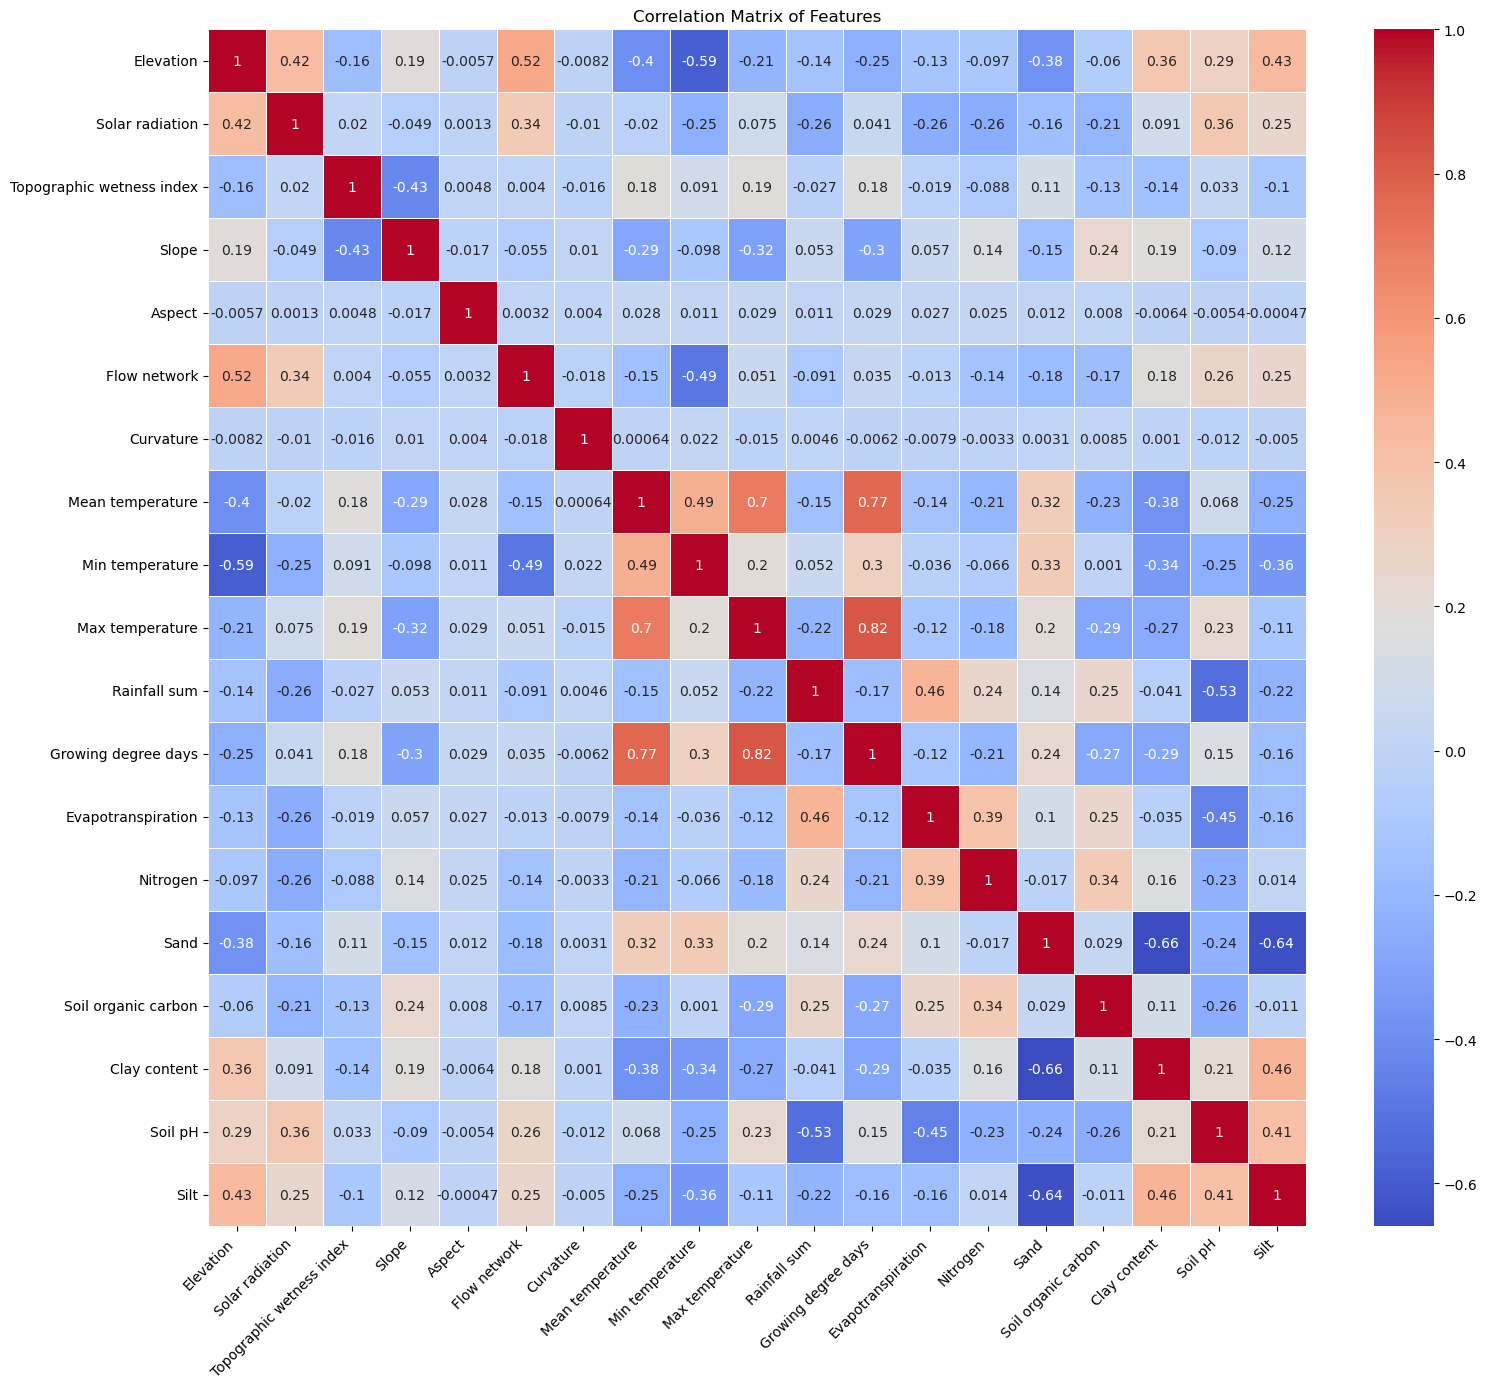

In [23]:
# Correlation matrix of features

# drop OID__, POINT_X, POINT_Y, suitability columns 
columns_to_drop = ['suitability', 'OID_', 'POINT_X', 'POINT_Y'] 
features = combined_df.drop(columns=columns_to_drop)

# Rename the columns
features = features.rename(columns=custom_names)

plt.figure(figsize=(16, 14))
correlation_matrix = features.corr(method='kendall')
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Distribution of each feature
plt.figure(figsize=(15, 10))
for i, column in enumerate(combined_df.columns[3:12], 1):
    plt.subplot(3, 3, i)
    sns.histplot(combined_df[column], kde=True)
    plt.title(column)
plt.tight_layout()
plt.show()

In [ ]:
# Distribution of each feature
plt.figure(figsize=(15, 10))
for i, column in enumerate(combined_df.columns[12:21], 1):
    plt.subplot(3, 3, i)
    sns.histplot(combined_df[column], kde=True)
    plt.title(column)
plt.tight_layout()
plt.show()

In [ ]:
# Distribution of each feature
plt.figure(figsize=(15, 10))
for i, column in enumerate(combined_df.columns[21:], 1):
    plt.subplot(3, 3, i)
    sns.histplot(combined_df[column], kde=True)
    plt.title(column)
plt.tight_layout()
plt.show()

In [ ]:
# Geographical distribution (if latitude and longitude are available)

# plt.figure(figsize=(12, 8))
# plt.scatter(combined_df[combined_df['suitability'] == 0]['POINT_X'], 
#             combined_df[combined_df['suitability'] == 0]['POINT_Y'], 
#             alpha=0.2, label='Absence')
# plt.scatter(combined_df[combined_df['suitability'] == 1]['POINT_X'], 
#             combined_df[combined_df['suitability'] == 1]['POINT_Y'], 
#             alpha=0.2, label='Presence')
# plt.title('Geographical Distribution of Points')
# plt.xlabel('Longitude')
# plt.ylabel('Latitude')
# plt.legend()
# plt.show()

## Model training

In [127]:
# I can potentially look at normalizing the data see the example below

# from sklearn.preprocessing import StandardScaler

# Normalizing 
# No need to normalize binary or Likert Scaled columns. 

# columns_to_normalize = df.columns[1:5] 

# Initialize the StandardScaler

# scaler = StandardScaler()

# Fit and transform the selected columns

# df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])

In [81]:
# columns to drop
# I am dropping the suitability column because it is the target variable and OID column because it is an identifier and to reduce overfitting and noise 
# I can potentially drop the geometry columns as well?? 
# We can potentially drop POINT_X and POINT_Y because they are location identifiers rather than predictive features
# But if geographical location is important we can potentially keep them
columns_to_drop = ['suitability', 'OID_', 'POINT_X', 'POINT_Y'] 

# features/ predictor variables
X = combined_df.drop(columns=columns_to_drop)

# target variable (0 and 1)
y = combined_df['suitability']




In [82]:
# Create a train/test split with 20% as test size
# random_state controls the shuffling applied to the data before applying the split
# What does the value 42 signify now?
# What difference would it have made if I had use another value??
# I believe that 42 has been determined to be an optimal/default value for best model performance


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Scale the features
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

In [83]:
# check for duplicates between training and test data (this checks for duplicates in the respective df)
# X_train.duplicated().sum()
# X_test.duplicated().sum()

# Create complete datasets for training and testing
train_data = pd.concat([X_train, y_train], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

train_data.shape
test_data.shape

# Check for duplicates between training and testing data
duplicates_df = pd.concat([train_data, test_data])
duplicates = pd.concat([train_data, test_data]).duplicated().sum()

duplicates_df.size

print(f"Number of duplicates between training and testing data: {duplicates}")

# to see the actual duplicate rows:
# duplicate_rows = pd.concat([train_data, test_data])[pd.concat([train_data, test_data]).duplicated(keep=False)]
# print("Duplicate rows:")
# print(duplicate_rows)

(73776, 20)

(18444, 20)

1844400

Number of duplicates between training and testing data: 27689


In [84]:

# Initialize the XGBoost regressor
# There is also a XGBClassifier 
#  The XGBRegressor class in the XGBoost Python API is used for regression problems 

xgb_model = XGBRegressor(objective='reg:logistic', random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test)



# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
# accuracy = accuracy_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.4f}")

# print(y_pred[0:100])
# Model results without ndvi, roads, and rivers
# Mean Absolute Error: 0.0532
# Mean Squared Error: 0.0258
# R-squared Score: 0.8967


# Model results from using standardised data (although the data has duplicates 22792)
# Mean Absolute Error: 0.0574
# Mean Squared Error: 0.0271
# R-squared Score: 0.8915

# Model results from using standardised data after removing most the duplicates between traing and testing data (4444)
# Mean Absolute Error: 0.0573
# Mean Squared Error: 0.0269
# R-squared Score: 0.8924



XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, objective='reg:logistic', ...)

Mean Absolute Error: 0.0583
Mean Squared Error: 0.0272
R-squared Score: 0.8911


## Predicting suitability for new locations

In [85]:
# Reading in points that have not been standardised and are ready for prediction
new_locations_df = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/input_points_data/points_for_predicting/non_standardised_wc_points_from_composite_raster.csv', delimiter=';')

# Reading the points that have been standardised and are ready for prediction
# new_locations_df = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/input_points_data/points_for_predicting/standardised_wc_points_from_composite_raster_fuzzy_linear.csv', delimiter=';')

print("New locations", new_locations_df.shape)

New locations (129425, 22)


In [86]:
print("New locations")
new_locations_df.head()
new_locations_df.describe()
new_locations_df.shape

New locations


,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_albers_k30_wc,composite_temp_min_1000m_albers_k30_wc,composite_temp_max_1000m_albers_k30_wc,composite_rainfall_sum_1000m_albers_k30_wc,composite_gdd_grapes_1000m_albers_wc,composite_AETI_1000m_albers_wc,nitrogen_15_to_30cm_1000m_albers_wc,sand_15_to_30cm_1000m_albers_wc,soc_15_to_30cm_1000m_albers_wc,clay_content_15_to_30cm_1000m_albers_wc,soil_ph_15_to_30cm_1000m_albers_wc,silt_15_to_30cm_1000m_albers_wc
0,1,"17,881470420327695","-32,989886923320924","13,3591509","1389262,3750000","9,0873699","1,0365752","8,2484989","1095,3914795","0,0501595",NaN,NaN,NaN,"45,4489326",NaN,"1860,1999512",142.0,777.0,224.0,154.0,70.0,68.0
1,2,"17,891267569177280","-32,989916735369036","26,3872833","1381197,0000000","6,7358322","1,3606182","294,9450989","2925,2165527","-0,0182552","17,7807350","12,7666912","23,9223289","46,3755913","2108,7475586","1271,4000244",130.0,780.0,240.0,150.0,73.0,70.0
2,3,"17,901064718274046","-32,989946506368661","24,4335155","1374246,1250000","7,7898469","3,3164825","283,4432373","3186,6374512","0,0690308","17,7294960","12,7256641","23,8594398","47,4036980","2097,6115723","892,7999878",133.0,772.0,204.0,147.0,71.0,81.0
3,4,"17,910861867617651","-32,989976236319599","25,7099609","1370007,8750000","8,4178047","1,5184340","227,7552948","5948,3007813","-0,0000000","17,4515495","12,5633955","23,4411144","48,4617500","2030,0032959","810,0000000",110.0,806.0,180.0,135.0,74.0,58.0
4,5,"17,920659017207750","-32,990005925221347","49,1808815","1350064,3750000","6,7119193","5,5577383","244,1683197","7462,0942383","0,1969528","17,3632793","12,5008907","23,3205452","49,5488358","2009,5540771","1141,0000000",88.0,819.0,145.0,117.0,70.0,64.0


,OID_,nitrogen_15_to_30cm_1000m_albers_wc,sand_15_to_30cm_1000m_albers_wc,soc_15_to_30cm_1000m_albers_wc,clay_content_15_to_30cm_1000m_albers_wc,soil_ph_15_to_30cm_1000m_albers_wc,silt_15_to_30cm_1000m_albers_wc
count,129425.000000,129199.000000,129199.000000,129199.000000,129199.000000,129199.00000,129199.000000
mean,64713.000000,90.786670,644.351837,140.550956,201.753055,72.73725,141.694053
std,37361.923632,39.338518,99.754249,65.505086,48.096977,10.00461,40.942546
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,32357.000000,60.000000,605.000000,95.000000,175.000000,69.00000,122.000000
50%,64713.000000,80.000000,641.000000,131.000000,205.000000,75.00000,144.000000
75%,97069.000000,116.000000,691.000000,173.000000,231.000000,79.00000,164.000000
max,129425.000000,374.000000,905.000000,836.000000,351.000000,85.00000,388.000000


(129425, 22)

In [87]:
new_locations_df.isnull().sum()

OID_                                                0
POINT_X                                             0
POINT_Y                                             0
sudem_1000m_albers_filled_wc                       19
sudem_1000m_albers_potential_solar_rad_wh2m_wc      0
sudem_1000m_albers_twi_d8_wc                       29
sudem_1000m_albers_slope_degree_wc                 29
sudem_1000m_albers_aspect_wc                       24
sudem_1000m_albers_flow_network_wc                409
sudem_1000m_albers_curvature_wc                   409
composite_temp_mean_1000m_albers_k30_wc           574
composite_temp_min_1000m_albers_k30_wc            574
composite_temp_max_1000m_albers_k30_wc            574
composite_rainfall_sum_1000m_albers_k30_wc        425
composite_gdd_grapes_1000m_albers_wc              574
composite_AETI_1000m_albers_wc                    341
nitrogen_15_to_30cm_1000m_albers_wc               226
sand_15_to_30cm_1000m_albers_wc                   226
soc_15_to_30cm_1000m_albers_

In [88]:
new_locations_df.dtypes

OID_                                                int64
POINT_X                                            object
POINT_Y                                            object
sudem_1000m_albers_filled_wc                       object
sudem_1000m_albers_potential_solar_rad_wh2m_wc     object
sudem_1000m_albers_twi_d8_wc                       object
sudem_1000m_albers_slope_degree_wc                 object
sudem_1000m_albers_aspect_wc                       object
sudem_1000m_albers_flow_network_wc                 object
sudem_1000m_albers_curvature_wc                    object
composite_temp_mean_1000m_albers_k30_wc            object
composite_temp_min_1000m_albers_k30_wc             object
composite_temp_max_1000m_albers_k30_wc             object
composite_rainfall_sum_1000m_albers_k30_wc         object
composite_gdd_grapes_1000m_albers_wc               object
composite_AETI_1000m_albers_wc                     object
nitrogen_15_to_30cm_1000m_albers_wc               float64
sand_15_to_30c

In [89]:
# Converting the columns to float

# This below is for the non-standardised data
columns_to_convert_for_new_locations = ['POINT_X','POINT_Y','sudem_1000m_albers_filled_wc', 'sudem_1000m_albers_potential_solar_rad_wh2m_wc',
                        'sudem_1000m_albers_twi_d8_wc', 'sudem_1000m_albers_slope_degree_wc',
                        'sudem_1000m_albers_aspect_wc', 'sudem_1000m_albers_flow_network_wc', 'sudem_1000m_albers_curvature_wc',
                        'composite_temp_mean_1000m_albers_k30_wc','composite_temp_min_1000m_albers_k30_wc', 'composite_temp_max_1000m_albers_k30_wc',
                        'composite_rainfall_sum_1000m_albers_k30_wc', 'composite_gdd_grapes_1000m_albers_wc', 'composite_AETI_1000m_albers_wc']


# This below is for the standardised data
# columns_to_convert_for_new_locations = ['POINT_X', 'POINT_Y', 'sudem_1000m_albers_filled_wc_fuzzy_linear', 'sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear',
#                         'sudem_1000m_albers_twi_d8_wc_fuzzy_linear', 'sudem_1000m_albers_slope_degree_wc_fuzzy_linear',
#                         'sudem_1000m_albers_aspect_wc_fuzzy_linear', 'sudem_1000m_albers_flow_network_wc_fuzzy_linear', 'sudem_1000m_albers_curvature_wc_fuzzy_linear',
#                         'composite_temp_mean_1000m_albers_k30_wc_fuzzy_linear', 'composite_temp_min_1000m_albers_k30_wc_fuzzy_linear', 'composite_temp_max_1000m_albers_k30_wc_fuzzy_linear',
#                         'composite_rainfall_sum_1000m_albers_k30_wc_fuzzy_linear', 'composite_gdd_grapes_1000m_albers_wc_fuzzy_linear', 'composite_AETI_1000m_albers_wc_fuzzy_linear',
#                         'nitrogen_15_to_30cm_1000m_albers_wc_fuzzy_linear', 'sand_15_to_30cm_1000m_albers_wc_fuzzy_linear', 'soc_15_to_30cm_1000m_albers_wc_fuzzy_linear',
#                         'clay_content_15_to_30cm_1000m_albers_wc_fuzzy_linear', 'soil_ph_15_to_30cm_1000m_albers_wc_fuzzy_linear', 'silt_15_to_30cm_1000m_albers_wc_fuzzy_linear']


for col in columns_to_convert_for_new_locations:
    new_locations_df[col] = clean_and_convert(new_locations_df[col])

In [90]:
# checking the data types again

new_locations_df.dtypes

OID_                                                int64
POINT_X                                           float64
POINT_Y                                           float64
sudem_1000m_albers_filled_wc                      float64
sudem_1000m_albers_potential_solar_rad_wh2m_wc    float64
sudem_1000m_albers_twi_d8_wc                      float64
sudem_1000m_albers_slope_degree_wc                float64
sudem_1000m_albers_aspect_wc                      float64
sudem_1000m_albers_flow_network_wc                float64
sudem_1000m_albers_curvature_wc                   float64
composite_temp_mean_1000m_albers_k30_wc           float64
composite_temp_min_1000m_albers_k30_wc            float64
composite_temp_max_1000m_albers_k30_wc            float64
composite_rainfall_sum_1000m_albers_k30_wc        float64
composite_gdd_grapes_1000m_albers_wc              float64
composite_AETI_1000m_albers_wc                    float64
nitrogen_15_to_30cm_1000m_albers_wc               float64
sand_15_to_30c

In [91]:
new_locations_df

# creating a new df called new_locations_df_2 to use for the csv file
new_locations_df_2 = new_locations_df.copy()

new_locations_df_2

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_albers_k30_wc,composite_temp_min_1000m_albers_k30_wc,composite_temp_max_1000m_albers_k30_wc,composite_rainfall_sum_1000m_albers_k30_wc,composite_gdd_grapes_1000m_albers_wc,composite_AETI_1000m_albers_wc,nitrogen_15_to_30cm_1000m_albers_wc,sand_15_to_30cm_1000m_albers_wc,soc_15_to_30cm_1000m_albers_wc,clay_content_15_to_30cm_1000m_albers_wc,soil_ph_15_to_30cm_1000m_albers_wc,silt_15_to_30cm_1000m_albers_wc
0,1,17.881470,-32.989887,13.359151,1389262.375,9.087370,1.036575,8.248499,1095.391480,0.050160,NaN,NaN,NaN,45.448933,NaN,1860.199951,142.0,777.0,224.0,154.0,70.0,68.0
1,2,17.891268,-32.989917,26.387283,1381197.000,6.735832,1.360618,294.945099,2925.216553,-0.018255,17.780735,12.766691,23.922329,46.375591,2108.747559,1271.400024,130.0,780.0,240.0,150.0,73.0,70.0
2,3,17.901065,-32.989947,24.433515,1374246.125,7.789847,3.316483,283.443237,3186.637451,0.069031,17.729496,12.725664,23.859440,47.403698,2097.611572,892.799988,133.0,772.0,204.0,147.0,71.0,81.0
3,4,17.910862,-32.989976,25.709961,1370007.875,8.417805,1.518434,227.755295,5948.300781,-0.000000,17.451549,12.563396,23.441114,48.461750,2030.003296,810.000000,110.0,806.0,180.0,135.0,74.0,58.0
4,5,17.920659,-32.990006,49.180881,1350064.375,6.711919,5.557738,244.168320,7462.094238,0.196953,17.363279,12.500891,23.320545,49.548836,2009.554077,1141.000000,88.0,819.0,145.0,117.0,70.0,64.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129420,129421,18.905077,-31.188113,247.035202,1456296.000,8.731962,0.787950,187.859665,146027.515625,0.012604,19.303942,12.678679,27.476919,74.903519,2572.736328,363.000000,69.0,739.0,97.0,144.0,81.0,118.0
129421,129422,18.914866,-31.188138,249.802139,1456493.875,12.183557,1.087181,188.204681,147801.031250,-0.112808,19.282606,12.656694,27.453869,75.817795,2569.142334,399.399994,62.0,757.0,94.0,134.0,80.0,110.0
129422,129423,18.924656,-31.188163,257.306549,1456531.375,9.989520,0.735975,117.813377,155471.031250,0.047943,19.264301,12.636481,27.435440,76.658493,2566.310059,369.200012,62.0,757.0,83.0,129.0,79.0,115.0
129423,129424,18.934446,-31.188188,268.275085,1464708.875,6.603725,1.552691,298.022675,156187.984375,0.046692,19.242565,12.614604,27.411152,77.414146,2562.600098,406.399994,59.0,753.0,91.0,133.0,79.0,114.0


,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_albers_k30_wc,composite_temp_min_1000m_albers_k30_wc,composite_temp_max_1000m_albers_k30_wc,composite_rainfall_sum_1000m_albers_k30_wc,composite_gdd_grapes_1000m_albers_wc,composite_AETI_1000m_albers_wc,nitrogen_15_to_30cm_1000m_albers_wc,sand_15_to_30cm_1000m_albers_wc,soc_15_to_30cm_1000m_albers_wc,clay_content_15_to_30cm_1000m_albers_wc,soil_ph_15_to_30cm_1000m_albers_wc,silt_15_to_30cm_1000m_albers_wc
0,1,17.881470,-32.989887,13.359151,1389262.375,9.087370,1.036575,8.248499,1095.391480,0.050160,NaN,NaN,NaN,45.448933,NaN,1860.199951,142.0,777.0,224.0,154.0,70.0,68.0
1,2,17.891268,-32.989917,26.387283,1381197.000,6.735832,1.360618,294.945099,2925.216553,-0.018255,17.780735,12.766691,23.922329,46.375591,2108.747559,1271.400024,130.0,780.0,240.0,150.0,73.0,70.0
2,3,17.901065,-32.989947,24.433515,1374246.125,7.789847,3.316483,283.443237,3186.637451,0.069031,17.729496,12.725664,23.859440,47.403698,2097.611572,892.799988,133.0,772.0,204.0,147.0,71.0,81.0
3,4,17.910862,-32.989976,25.709961,1370007.875,8.417805,1.518434,227.755295,5948.300781,-0.000000,17.451549,12.563396,23.441114,48.461750,2030.003296,810.000000,110.0,806.0,180.0,135.0,74.0,58.0
4,5,17.920659,-32.990006,49.180881,1350064.375,6.711919,5.557738,244.168320,7462.094238,0.196953,17.363279,12.500891,23.320545,49.548836,2009.554077,1141.000000,88.0,819.0,145.0,117.0,70.0,64.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129420,129421,18.905077,-31.188113,247.035202,1456296.000,8.731962,0.787950,187.859665,146027.515625,0.012604,19.303942,12.678679,27.476919,74.903519,2572.736328,363.000000,69.0,739.0,97.0,144.0,81.0,118.0
129421,129422,18.914866,-31.188138,249.802139,1456493.875,12.183557,1.087181,188.204681,147801.031250,-0.112808,19.282606,12.656694,27.453869,75.817795,2569.142334,399.399994,62.0,757.0,94.0,134.0,80.0,110.0
129422,129423,18.924656,-31.188163,257.306549,1456531.375,9.989520,0.735975,117.813377,155471.031250,0.047943,19.264301,12.636481,27.435440,76.658493,2566.310059,369.200012,62.0,757.0,83.0,129.0,79.0,115.0
129423,129424,18.934446,-31.188188,268.275085,1464708.875,6.603725,1.552691,298.022675,156187.984375,0.046692,19.242565,12.614604,27.411152,77.414146,2562.600098,406.399994,59.0,753.0,91.0,133.0,79.0,114.0


In [92]:
def interpolate_columns(df, columns):
    for col in columns:
        df[col].interpolate(method='linear', inplace=True)
    return df

In [93]:
# interpolate the columns with null values

# This below is for the non-standardised data
columns_to_interpolate_for_new_locations = ['sudem_1000m_albers_filled_wc', 'sudem_1000m_albers_potential_solar_rad_wh2m_wc',
                                            'sudem_1000m_albers_twi_d8_wc', 'sudem_1000m_albers_slope_degree_wc',
                                            'sudem_1000m_albers_aspect_wc', 'sudem_1000m_albers_flow_network_wc', 'sudem_1000m_albers_curvature_wc',
                                            'composite_temp_mean_1000m_albers_k30_wc','composite_temp_min_1000m_albers_k30_wc', 'composite_temp_max_1000m_albers_k30_wc',
                                            'composite_rainfall_sum_1000m_albers_k30_wc', 'composite_gdd_grapes_1000m_albers_wc', 'composite_AETI_1000m_albers_wc',
                                            'nitrogen_15_to_30cm_1000m_albers_wc', 'sand_15_to_30cm_1000m_albers_wc', 'soc_15_to_30cm_1000m_albers_wc',
                                            'clay_content_15_to_30cm_1000m_albers_wc', 'soil_ph_15_to_30cm_1000m_albers_wc', 'silt_15_to_30cm_1000m_albers_wc']

# This below is for the standardised data
# columns_to_interpolate_for_new_locations = ['POINT_X', 'POINT_Y', 'sudem_1000m_albers_filled_wc_fuzzy_linear', 'sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear',
#                         'sudem_1000m_albers_twi_d8_wc_fuzzy_linear', 'sudem_1000m_albers_slope_degree_wc_fuzzy_linear',
#                         'sudem_1000m_albers_aspect_wc_fuzzy_linear', 'sudem_1000m_albers_flow_network_wc_fuzzy_linear', 'sudem_1000m_albers_curvature_wc_fuzzy_linear',
#                         'composite_temp_mean_1000m_albers_k30_wc_fuzzy_linear', 'composite_temp_min_1000m_albers_k30_wc_fuzzy_linear', 'composite_temp_max_1000m_albers_k30_wc_fuzzy_linear',
#                         'composite_rainfall_sum_1000m_albers_k30_wc_fuzzy_linear', 'composite_gdd_grapes_1000m_albers_wc_fuzzy_linear', 'composite_AETI_1000m_albers_wc_fuzzy_linear',
#                         'nitrogen_15_to_30cm_1000m_albers_wc_fuzzy_linear', 'sand_15_to_30cm_1000m_albers_wc_fuzzy_linear', 'soc_15_to_30cm_1000m_albers_wc_fuzzy_linear',
#                         'clay_content_15_to_30cm_1000m_albers_wc_fuzzy_linear', 'soil_ph_15_to_30cm_1000m_albers_wc_fuzzy_linear', 'silt_15_to_30cm_1000m_albers_wc_fuzzy_linear']


interpolate_columns(new_locations_df, columns_to_interpolate_for_new_locations)

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_albers_k30_wc,composite_temp_min_1000m_albers_k30_wc,composite_temp_max_1000m_albers_k30_wc,composite_rainfall_sum_1000m_albers_k30_wc,composite_gdd_grapes_1000m_albers_wc,composite_AETI_1000m_albers_wc,nitrogen_15_to_30cm_1000m_albers_wc,sand_15_to_30cm_1000m_albers_wc,soc_15_to_30cm_1000m_albers_wc,clay_content_15_to_30cm_1000m_albers_wc,soil_ph_15_to_30cm_1000m_albers_wc,silt_15_to_30cm_1000m_albers_wc
0,1,17.881470,-32.989887,13.359151,1389262.375,9.087370,1.036575,8.248499,1095.391480,0.050160,NaN,NaN,NaN,45.448933,NaN,1860.199951,142.0,777.0,224.0,154.0,70.0,68.0
1,2,17.891268,-32.989917,26.387283,1381197.000,6.735832,1.360618,294.945099,2925.216553,-0.018255,17.780735,12.766691,23.922329,46.375591,2108.747559,1271.400024,130.0,780.0,240.0,150.0,73.0,70.0
2,3,17.901065,-32.989947,24.433515,1374246.125,7.789847,3.316483,283.443237,3186.637451,0.069031,17.729496,12.725664,23.859440,47.403698,2097.611572,892.799988,133.0,772.0,204.0,147.0,71.0,81.0
3,4,17.910862,-32.989976,25.709961,1370007.875,8.417805,1.518434,227.755295,5948.300781,-0.000000,17.451549,12.563396,23.441114,48.461750,2030.003296,810.000000,110.0,806.0,180.0,135.0,74.0,58.0
4,5,17.920659,-32.990006,49.180881,1350064.375,6.711919,5.557738,244.168320,7462.094238,0.196953,17.363279,12.500891,23.320545,49.548836,2009.554077,1141.000000,88.0,819.0,145.0,117.0,70.0,64.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129420,129421,18.905077,-31.188113,247.035202,1456296.000,8.731962,0.787950,187.859665,146027.515625,0.012604,19.303942,12.678679,27.476919,74.903519,2572.736328,363.000000,69.0,739.0,97.0,144.0,81.0,118.0
129421,129422,18.914866,-31.188138,249.802139,1456493.875,12.183557,1.087181,188.204681,147801.031250,-0.112808,19.282606,12.656694,27.453869,75.817795,2569.142334,399.399994,62.0,757.0,94.0,134.0,80.0,110.0
129422,129423,18.924656,-31.188163,257.306549,1456531.375,9.989520,0.735975,117.813377,155471.031250,0.047943,19.264301,12.636481,27.435440,76.658493,2566.310059,369.200012,62.0,757.0,83.0,129.0,79.0,115.0
129423,129424,18.934446,-31.188188,268.275085,1464708.875,6.603725,1.552691,298.022675,156187.984375,0.046692,19.242565,12.614604,27.411152,77.414146,2562.600098,406.399994,59.0,753.0,91.0,133.0,79.0,114.0


In [94]:
new_locations_df.isnull().sum()
new_locations_df.shape

OID_                                              0
POINT_X                                           0
POINT_Y                                           0
sudem_1000m_albers_filled_wc                      0
sudem_1000m_albers_potential_solar_rad_wh2m_wc    0
sudem_1000m_albers_twi_d8_wc                      0
sudem_1000m_albers_slope_degree_wc                0
sudem_1000m_albers_aspect_wc                      0
sudem_1000m_albers_flow_network_wc                0
sudem_1000m_albers_curvature_wc                   0
composite_temp_mean_1000m_albers_k30_wc           1
composite_temp_min_1000m_albers_k30_wc            1
composite_temp_max_1000m_albers_k30_wc            1
composite_rainfall_sum_1000m_albers_k30_wc        0
composite_gdd_grapes_1000m_albers_wc              1
composite_AETI_1000m_albers_wc                    0
nitrogen_15_to_30cm_1000m_albers_wc               0
sand_15_to_30cm_1000m_albers_wc                   0
soc_15_to_30cm_1000m_albers_wc                    0
clay_content

(129425, 22)

In [95]:
new_locations_df.dropna(inplace=True)
new_locations_df.isnull().sum()
new_locations_df.shape

OID_                                              0
POINT_X                                           0
POINT_Y                                           0
sudem_1000m_albers_filled_wc                      0
sudem_1000m_albers_potential_solar_rad_wh2m_wc    0
sudem_1000m_albers_twi_d8_wc                      0
sudem_1000m_albers_slope_degree_wc                0
sudem_1000m_albers_aspect_wc                      0
sudem_1000m_albers_flow_network_wc                0
sudem_1000m_albers_curvature_wc                   0
composite_temp_mean_1000m_albers_k30_wc           0
composite_temp_min_1000m_albers_k30_wc            0
composite_temp_max_1000m_albers_k30_wc            0
composite_rainfall_sum_1000m_albers_k30_wc        0
composite_gdd_grapes_1000m_albers_wc              0
composite_AETI_1000m_albers_wc                    0
nitrogen_15_to_30cm_1000m_albers_wc               0
sand_15_to_30cm_1000m_albers_wc                   0
soc_15_to_30cm_1000m_albers_wc                    0
clay_content

(129424, 22)

In [96]:
original_point_x = new_locations_df['POINT_X']
original_point_y = new_locations_df['POINT_Y']

In [97]:
# Make predictions
columns_to_drop_2 = ['OID_', 'POINT_X', 'POINT_Y']

new_locations_df.drop(columns=columns_to_drop_2, inplace=True)
feature_names = xgb_model.get_booster().feature_names
new_locations_df = new_locations_df[feature_names]
suitability_scores = xgb_model.predict(new_locations_df)


In [98]:
# Add predictions to the new_locations dataframe
new_locations_df['suitability_score'] = suitability_scores

# Might need to rearrange the columns according to point_x and point_y 

# new_locations_df.describe



# Add POINT_X and POINT_Y columns back to the dataframe
new_locations_df['POINT_X'] = original_point_x
new_locations_df['POINT_Y'] = original_point_y

In [99]:
# Save results
# Saving the results for the non-standardised data
new_locations_df.to_csv('../output_points_data/prediction_on_all_features/non_standardised_wc_predicted_suitability_all_features.csv', index=False)


# If i can save it with point_x and point_y that would be great
# Saving the results for the standardised data
# new_locations_df.to_csv('../output_points_data/prediction_on_all_features/standardised_wc_predicted_suitability_fuzzy_linear_all_features.csv', index=False)

In [100]:
# Read in the results for non-standardised data
wc_predicted_suitability = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/output_points_data/prediction_on_all_features/non_standardised_wc_predicted_suitability_all_features.csv')        


# Read in the results for standardised data
# wc_predicted_suitability = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/output_points_data/prediction_on_all_features/standardised_wc_predicted_suitability_fuzzy_linear_all_features.csv')        

In [101]:
wc_predicted_suitability.head()
wc_predicted_suitability['suitability_score'].describe()

# So 

,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_albers_k30_wc,composite_temp_min_1000m_albers_k30_wc,composite_temp_max_1000m_albers_k30_wc,composite_rainfall_sum_1000m_albers_k30_wc,composite_gdd_grapes_1000m_albers_wc,composite_AETI_1000m_albers_wc,nitrogen_15_to_30cm_1000m_albers_wc,sand_15_to_30cm_1000m_albers_wc,soc_15_to_30cm_1000m_albers_wc,clay_content_15_to_30cm_1000m_albers_wc,soil_ph_15_to_30cm_1000m_albers_wc,silt_15_to_30cm_1000m_albers_wc,suitability_score,POINT_X,POINT_Y
0,26.387283,1381197.000,6.735832,1.360618,294.945099,2925.216553,-0.018255,17.780735,12.766691,23.922329,46.375591,2108.747559,1271.400024,130.0,780.0,240.0,150.0,73.0,70.0,0.000157,17.891268,-32.989917
1,24.433515,1374246.125,7.789847,3.316483,283.443237,3186.637451,0.069031,17.729496,12.725664,23.859440,47.403698,2097.611572,892.799988,133.0,772.0,204.0,147.0,71.0,81.0,0.003173,17.901065,-32.989947
2,25.709961,1370007.875,8.417805,1.518434,227.755295,5948.300781,-0.000000,17.451549,12.563396,23.441114,48.461750,2030.003296,810.000000,110.0,806.0,180.0,135.0,74.0,58.0,0.000498,17.910862,-32.989976
3,49.180881,1350064.375,6.711919,5.557738,244.168320,7462.094238,0.196953,17.363279,12.500891,23.320545,49.548836,2009.554077,1141.000000,88.0,819.0,145.0,117.0,70.0,64.0,0.000751,17.920659,-32.990006
4,98.710983,1378391.500,8.674533,1.370459,257.219055,7462.094238,0.196953,17.528072,12.583695,23.584442,50.663734,2050.475830,1546.599976,100.0,812.0,154.0,128.0,74.0,60.0,0.001377,17.930456,-32.990036


count    1.294240e+05
mean     6.640600e-02
std      2.002456e-01
min      3.309687e-07
25%      1.123476e-04
50%      8.646108e-04
75%      1.062248e-02
max      9.995769e-01
Name: suitability_score, dtype: float64

In [102]:
# wc_vineyard_locations only has the suitability score
wc_vineyard_suitability_score = wc_predicted_suitability['suitability_score']

In [103]:
# Output for the non-standardised data
wc_vineyard_suitability_score.to_csv('../output_points_data/prediction_on_all_features/only_vineyard_suitability_score_wc_non_standardised_all_features.csv', index=False)


# Output for the standardised data
# wc_vineyard_suitability_score.to_csv('../output_points_data/prediction_on_all_features/only_vineyard_suitability_score_wc_standardised_fuzzy_linear_all_features.csv', index=False)
new_locations_df_2

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc,sudem_1000m_albers_potential_solar_rad_wh2m_wc,sudem_1000m_albers_twi_d8_wc,sudem_1000m_albers_slope_degree_wc,sudem_1000m_albers_aspect_wc,sudem_1000m_albers_flow_network_wc,sudem_1000m_albers_curvature_wc,composite_temp_mean_1000m_albers_k30_wc,composite_temp_min_1000m_albers_k30_wc,composite_temp_max_1000m_albers_k30_wc,composite_rainfall_sum_1000m_albers_k30_wc,composite_gdd_grapes_1000m_albers_wc,composite_AETI_1000m_albers_wc,nitrogen_15_to_30cm_1000m_albers_wc,sand_15_to_30cm_1000m_albers_wc,soc_15_to_30cm_1000m_albers_wc,clay_content_15_to_30cm_1000m_albers_wc,soil_ph_15_to_30cm_1000m_albers_wc,silt_15_to_30cm_1000m_albers_wc
0,1,17.881470,-32.989887,13.359151,1389262.375,9.087370,1.036575,8.248499,1095.391480,0.050160,NaN,NaN,NaN,45.448933,NaN,1860.199951,142.0,777.0,224.0,154.0,70.0,68.0
1,2,17.891268,-32.989917,26.387283,1381197.000,6.735832,1.360618,294.945099,2925.216553,-0.018255,17.780735,12.766691,23.922329,46.375591,2108.747559,1271.400024,130.0,780.0,240.0,150.0,73.0,70.0
2,3,17.901065,-32.989947,24.433515,1374246.125,7.789847,3.316483,283.443237,3186.637451,0.069031,17.729496,12.725664,23.859440,47.403698,2097.611572,892.799988,133.0,772.0,204.0,147.0,71.0,81.0
3,4,17.910862,-32.989976,25.709961,1370007.875,8.417805,1.518434,227.755295,5948.300781,-0.000000,17.451549,12.563396,23.441114,48.461750,2030.003296,810.000000,110.0,806.0,180.0,135.0,74.0,58.0
4,5,17.920659,-32.990006,49.180881,1350064.375,6.711919,5.557738,244.168320,7462.094238,0.196953,17.363279,12.500891,23.320545,49.548836,2009.554077,1141.000000,88.0,819.0,145.0,117.0,70.0,64.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129420,129421,18.905077,-31.188113,247.035202,1456296.000,8.731962,0.787950,187.859665,146027.515625,0.012604,19.303942,12.678679,27.476919,74.903519,2572.736328,363.000000,69.0,739.0,97.0,144.0,81.0,118.0
129421,129422,18.914866,-31.188138,249.802139,1456493.875,12.183557,1.087181,188.204681,147801.031250,-0.112808,19.282606,12.656694,27.453869,75.817795,2569.142334,399.399994,62.0,757.0,94.0,134.0,80.0,110.0
129422,129423,18.924656,-31.188163,257.306549,1456531.375,9.989520,0.735975,117.813377,155471.031250,0.047943,19.264301,12.636481,27.435440,76.658493,2566.310059,369.200012,62.0,757.0,83.0,129.0,79.0,115.0
129423,129424,18.934446,-31.188188,268.275085,1464708.875,6.603725,1.552691,298.022675,156187.984375,0.046692,19.242565,12.614604,27.411152,77.414146,2562.600098,406.399994,59.0,753.0,91.0,133.0,79.0,114.0


In [104]:
location_columns = ['POINT_X', 'POINT_Y']
merged_df = pd.concat([wc_vineyard_suitability_score, new_locations_df_2[location_columns]], axis=1)

merged_df

,suitability_score,POINT_X,POINT_Y
0,0.000157,17.881470,-32.989887
1,0.003173,17.891268,-32.989917
2,0.000498,17.901065,-32.989947
3,0.000751,17.910862,-32.989976
4,0.001377,17.920659,-32.990006
...,...,...,...
129420,0.000160,18.905077,-31.188113
129421,0.000589,18.914866,-31.188138
129422,0.000337,18.924656,-31.188163
129423,0.000245,18.934446,-31.188188


In [105]:
merged_df.isnull().sum()
merged_df.dropna(inplace=True)

suitability_score    1
POINT_X              0
POINT_Y              0
dtype: int64

In [106]:
# Points with suitability score
merged_df

,suitability_score,POINT_X,POINT_Y
0,0.000157,17.881470,-32.989887
1,0.003173,17.891268,-32.989917
2,0.000498,17.901065,-32.989947
3,0.000751,17.910862,-32.989976
4,0.001377,17.920659,-32.990006
...,...,...,...
129419,0.000188,18.895287,-31.188087
129420,0.000160,18.905077,-31.188113
129421,0.000589,18.914866,-31.188138
129422,0.000337,18.924656,-31.188163


In [52]:
# After this i go into ArcPro and create a point shapefile from the csv file using the XY to point tool
# I then create a raster from the point shapefile using the raster to point tool


## Feature importance

### RFE feature importance

In [107]:
# Create the RFE selector
# n_features_to_select is the number of features you want to select
rfe_selector = RFE(estimator=xgb_model, n_features_to_select=5, step=1)

# Fit RFE
rfe_selector = rfe_selector.fit(X_train, y_train)

# Get the selected features
selected_features_rfe = X_train.columns[rfe_selector.support_]

print("Selected features:", selected_features_rfe)

Selected features: Index(['sudem_1000m_albers_filled_wc',
       'composite_temp_max_1000m_albers_k30_wc',
       'composite_AETI_1000m_albers_wc', 'sand_15_to_30cm_1000m_albers_wc',
       'soil_ph_15_to_30cm_1000m_albers_wc'],
      dtype='object')


<Figure size 1000x1200 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Feature Ranking (RFE)')

Text(0, 0.5, 'Features')

Text(0.5, 0, 'Ranking (Lower is better)')

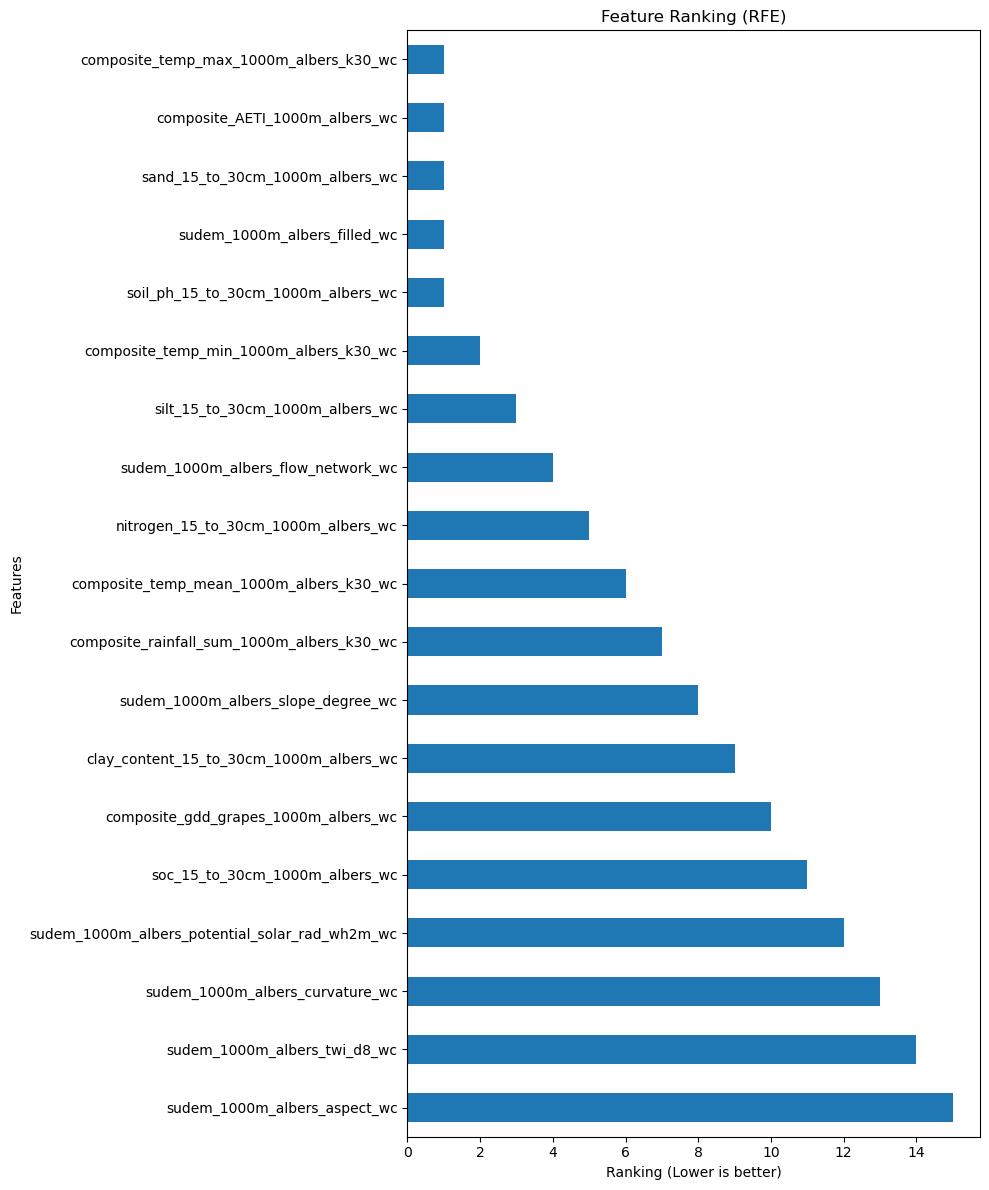

In [108]:
# plot feature importance from RFE
# Get feature ranking
feature_ranking = pd.Series(rfe_selector.ranking_, index=X_train.columns)

# Sort features by ranking
sorted_features = feature_ranking.sort_values(ascending=False)

# For all features
# Create a horizontal bar plot
plt.figure(figsize=(10, 12))  # Adjust figure size as needed
sorted_features.plot(kind='barh')  # 'barh' creates a horizontal bar plot
plt.title('Feature Ranking (RFE)')
plt.ylabel('Features')
plt.xlabel('Ranking (Lower is better)')
plt.tight_layout()
plt.show()

### ANOVA feature importance

In [109]:
def anova_feature_selection(X, y):
    # Perform f_regression
    f_statistic, p_values = f_regression(X, y)
    
    # Create a dataframe of features and their p-values
    feature_scores = pd.DataFrame({
        'Feature': X.columns,
        'F-statistic': f_statistic,
        'p-value': p_values
    })
    
    # Sort features by p-value
    feature_scores = feature_scores.sort_values('p-value')
    
    return feature_scores

# Use the function
anova_scores = anova_feature_selection(X_train, y_train)

# Display the results
print(anova_scores)
print('\n')
print(anova_scores['F-statistic'].sort_values(ascending=False))

                                           Feature   F-statistic  \
0                     sudem_1000m_albers_filled_wc  29827.954286   
16         clay_content_15_to_30cm_1000m_albers_wc   8851.300630   
15                  soc_15_to_30cm_1000m_albers_wc   2178.901822   
14                 sand_15_to_30cm_1000m_albers_wc   3384.481011   
13             nitrogen_15_to_30cm_1000m_albers_wc   4440.434034   
12                  composite_AETI_1000m_albers_wc  37513.525514   
11            composite_gdd_grapes_1000m_albers_wc   2396.746165   
10      composite_rainfall_sum_1000m_albers_k30_wc  15765.474775   
17              soil_ph_15_to_30cm_1000m_albers_wc  10672.301653   
9           composite_temp_max_1000m_albers_k30_wc   2023.884985   
7          composite_temp_mean_1000m_albers_k30_wc   3702.596941   
5               sudem_1000m_albers_flow_network_wc   2825.836309   
3               sudem_1000m_albers_slope_degree_wc   3856.947055   
1   sudem_1000m_albers_potential_solar_rad_wh2m_

In [110]:
# Select features with p-value < 0.05
selected_features_anova = anova_scores[anova_scores['F-statistic'] > 10000]['Feature'].tolist()

print("Selected features (ANOVA):", selected_features_anova)

# Important features from the ANOVA test for standardaised data
# sudem_1000m_albers_filled_wc_fuzzy_linear
# composite_AETI_1000m_albers_wc_fuzzy_linear
# composite_rainfall_sum_1000m_albers_k30_wc_fuzzy_linear
# soil_ph_15_to_30cm_1000m_albers_wc_fuzzy_linear
# silt_15_to_30cm_1000m_albers_wc_fuzzy_linear

Selected features (ANOVA): ['sudem_1000m_albers_filled_wc', 'composite_AETI_1000m_albers_wc', 'composite_rainfall_sum_1000m_albers_k30_wc', 'soil_ph_15_to_30cm_1000m_albers_wc', 'silt_15_to_30cm_1000m_albers_wc']


<Figure size 1200x800 with 0 Axes>

<BarContainer object of 19 artists>

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18],
 [Text(0, 0, 'sudem_1000m_albers_filled_wc'),
  Text(1, 0, 'clay_content_15_to_30cm_1000m_albers_wc'),
  Text(2, 0, 'soc_15_to_30cm_1000m_albers_wc'),
  Text(3, 0, 'sand_15_to_30cm_1000m_albers_wc'),
  Text(4, 0, 'nitrogen_15_to_30cm_1000m_albers_wc'),
  Text(5, 0, 'composite_AETI_1000m_albers_wc'),
  Text(6, 0, 'composite_gdd_grapes_1000m_albers_wc'),
  Text(7, 0, 'composite_rainfall_sum_1000m_albers_k30_wc'),
  Text(8, 0, 'soil_ph_15_to_30cm_1000m_albers_wc'),
  Text(9, 0, 'composite_temp_max_1000m_albers_k30_wc'),
  Text(10, 0, 'composite_temp_mean_1000m_albers_k30_wc'),
  Text(11, 0, 'sudem_1000m_albers_flow_network_wc'),
  Text(12, 0, 'sudem_1000m_albers_slope_degree_wc'),
  Text(13, 0, 'sudem_1000m_albers_potential_solar_rad_wh2m_wc'),
  Text(14, 0, 'composite_temp_min_1000m_albers_k30_wc'),
  Text(15, 0, 'silt_15_to_30cm_1000m_albers_wc'),
  Text(16, 0, 'sudem_1000m_albers_twi_d8_wc'),
  Text(17, 0, 'sudem_1000

Text(0, 0.5, 'F-statistic value')

Text(0.5, 1.0, 'Feature Importance (ANOVA)')

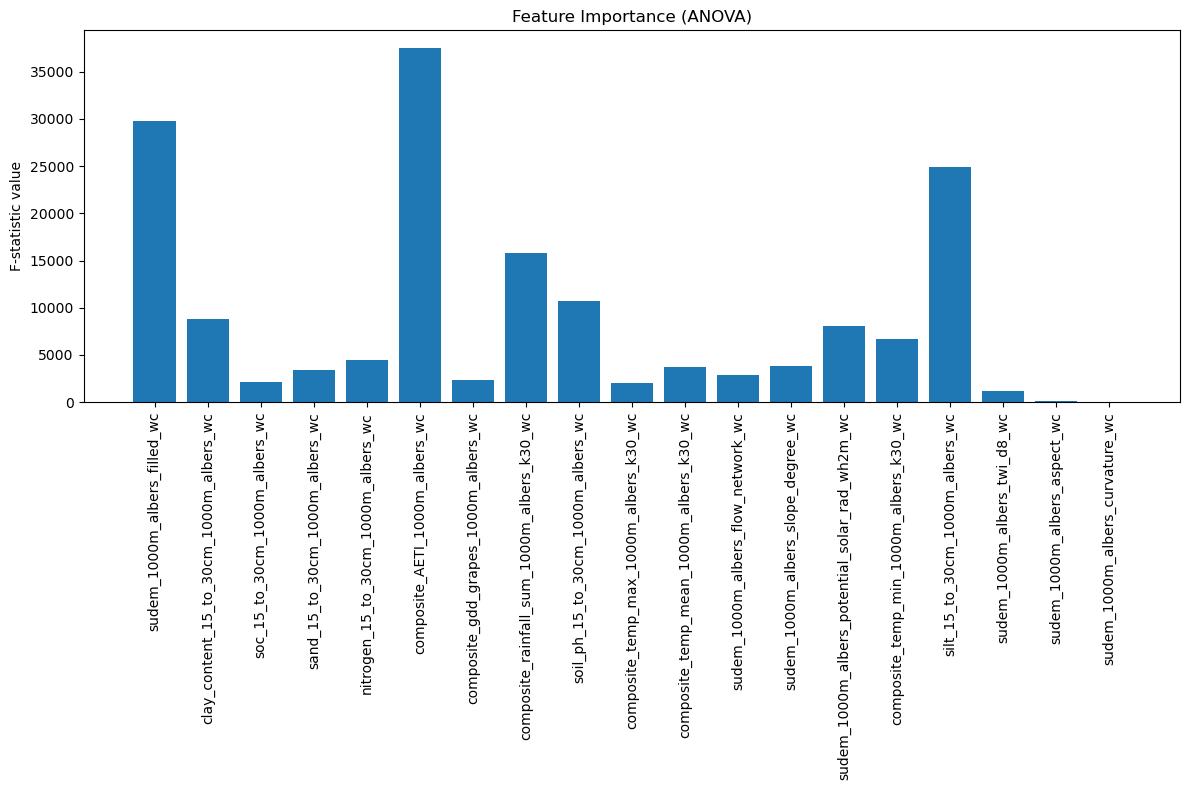

In [111]:

# plot feature importance from ANOVA
plt.figure(figsize=(12, 8))
plt.bar(anova_scores['Feature'], (anova_scores['F-statistic']))
plt.xticks(rotation=90)
plt.ylabel('F-statistic value')
plt.title('Feature Importance (ANOVA)')
plt.tight_layout()
plt.show()

### SFS

In [112]:
def sfs_feature_selection(X, y, n_features_to_select=5):
    # Create the XGBoost model
    # xgb_model = XGBRegressor(random_state=42)
    
    # Create the SFS selector
    sfs_selector = SequentialFeatureSelector(
        xgb_model, 
        n_features_to_select=n_features_to_select,
        direction='forward',
        scoring='neg_mean_squared_error',
        cv=5
    )
    
    # Fit SFS
    sfs_selector = sfs_selector.fit(X, y)
    
    # Get the selected feature names
    selected_features = X.columns[sfs_selector.support_].tolist()
    
    return selected_features, sfs_selector

# Use the function
n_features = 5  # You can adjust this number
selected_features_sfs, sfs_selector = sfs_feature_selection(X_train, y_train, n_features)

print("Selected features (SFS):", selected_features_sfs)

Selected features (SFS): ['sudem_1000m_albers_filled_wc', 'sudem_1000m_albers_flow_network_wc', 'composite_AETI_1000m_albers_wc', 'sand_15_to_30cm_1000m_albers_wc', 'soil_ph_15_to_30cm_1000m_albers_wc']


### In built feature importance

In [113]:
# Get feature importance (in b)
feature_importance = xgb_model.feature_importances_
feature_names = X.columns

# Sort features by importance
sorted_idx = np.argsort(feature_importance)
sorted_features = feature_names[sorted_idx]
selected_features_in_built = sorted_features[14:]
selected_features_in_built

Index(['composite_temp_max_1000m_albers_k30_wc',
       'soil_ph_15_to_30cm_1000m_albers_wc', 'sand_15_to_30cm_1000m_albers_wc',
       'composite_AETI_1000m_albers_wc', 'sudem_1000m_albers_filled_wc'],
      dtype='object')

<Figure size 1000x600 with 0 Axes>

<BarContainer object of 19 artists>

([<matplotlib.axis.YTick at 0x2489fd8a000>,
 [Text(0, 0, 'sudem_1000m_albers_aspect_wc'),
  Text(0, 1, 'sudem_1000m_albers_twi_d8_wc'),
  Text(0, 2, 'sudem_1000m_albers_curvature_wc'),
  Text(0, 3, 'sudem_1000m_albers_potential_solar_rad_wh2m_wc'),
  Text(0, 4, 'composite_gdd_grapes_1000m_albers_wc'),
  Text(0, 5, 'soc_15_to_30cm_1000m_albers_wc'),
  Text(0, 6, 'composite_rainfall_sum_1000m_albers_k30_wc'),
  Text(0, 7, 'clay_content_15_to_30cm_1000m_albers_wc'),
  Text(0, 8, 'nitrogen_15_to_30cm_1000m_albers_wc'),
  Text(0, 9, 'sudem_1000m_albers_slope_degree_wc'),
  Text(0, 10, 'sudem_1000m_albers_flow_network_wc'),
  Text(0, 11, 'composite_temp_mean_1000m_albers_k30_wc'),
  Text(0, 12, 'composite_temp_min_1000m_albers_k30_wc'),
  Text(0, 13, 'silt_15_to_30cm_1000m_albers_wc'),
  Text(0, 14, 'composite_temp_max_1000m_albers_k30_wc'),
  Text(0, 15, 'soil_ph_15_to_30cm_1000m_albers_wc'),
  Text(0, 16, 'sand_15_to_30cm_1000m_albers_wc'),
  Text(0, 17, 'composite_AETI_1000m_albers_wc'),


Text(0.5, 0, 'Importance')

Text(0.5, 1.0, 'Feature Importance')

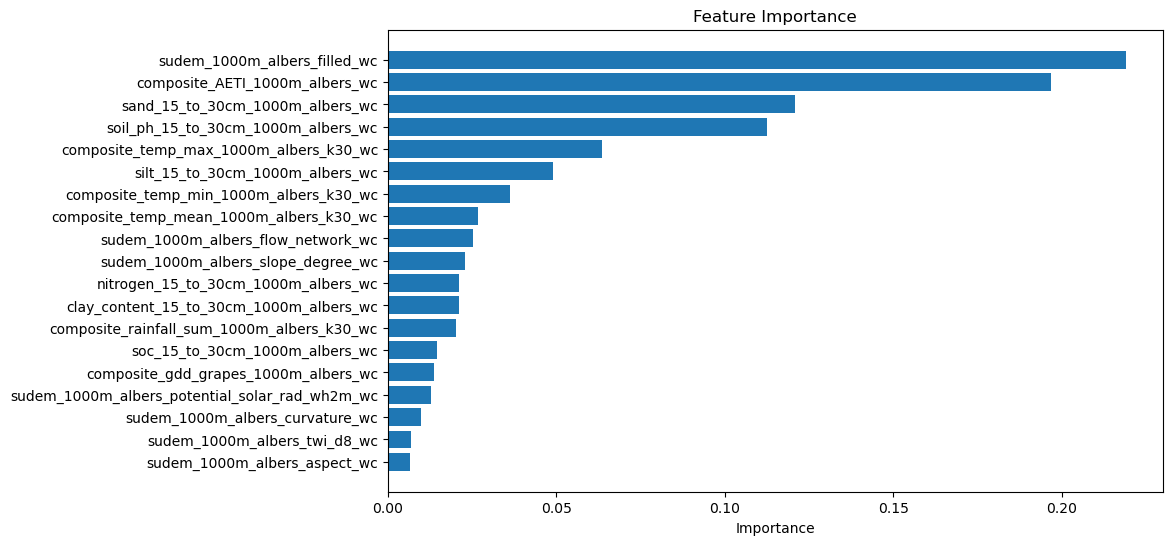

In [114]:
# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_features)), feature_importance[sorted_idx])
plt.yticks(range(len(sorted_features)), sorted_features)
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.show()

### Comparing feature selection methods

In [115]:

rfe_features = set(selected_features_rfe)
anova_features = set(selected_features_anova)
sfs_features = set(selected_features_sfs)
in_built_features = set(selected_features_in_built)

In [116]:
print("Features selected by all methods:", sfs_features.intersection(rfe_features, anova_features, in_built_features))

Features selected by all methods: {'composite_AETI_1000m_albers_wc', 'sudem_1000m_albers_filled_wc', 'soil_ph_15_to_30cm_1000m_albers_wc'}


### Training using top 5 selected features

In [117]:
# top 5 features from the model that was trained with non-standardised data
top_features = ['sudem_1000m_albers_filled_wc', 'composite_AETI_1000m_albers_wc', 'soil_ph_15_to_30cm_1000m_albers_wc', 'composite_temp_max_1000m_albers_k30_wc', 'sand_15_to_30cm_1000m_albers_wc']

# top 5 features from the model that was trained with standardised data
# top_features = ['sudem_1000m_albers_filled_wc_fuzzy_linear', 'soil_ph_15_to_30cm_1000m_albers_wc_fuzzy_linear', 'composite_AETI_1000m_albers_wc_fuzzy_linear', 'composite_temp_max_1000m_albers_k30_wc_fuzzy_linear', 'sand_15_to_30cm_1000m_albers_wc_fuzzy_linear']   



In [118]:
# only get the top features from the training and testing data
X_train_top_features = X_train[top_features]
X_test_top_features = X_test[top_features]

X_train_top_features.head()
X_test_top_features.head()

# only get the top features from the points that are used for prediction
new_locations_df_top_features = new_locations_df[top_features]

,sudem_1000m_albers_filled_wc,composite_AETI_1000m_albers_wc,soil_ph_15_to_30cm_1000m_albers_wc,composite_temp_max_1000m_albers_k30_wc,sand_15_to_30cm_1000m_albers_wc
18693,146.555740,6285.000000,63,23.925154,733
67445,655.187134,2243.000000,77,24.513298,608
62520,155.339081,2778.199951,71,26.422604,703
51747,763.737060,9125.200195,70,21.843101,615
38123,394.065765,7656.399902,66,23.556940,704


,sudem_1000m_albers_filled_wc,composite_AETI_1000m_albers_wc,soil_ph_15_to_30cm_1000m_albers_wc,composite_temp_max_1000m_albers_k30_wc,sand_15_to_30cm_1000m_albers_wc
48208,1137.451416,3955.600098,69,20.922024,652
36464,179.336960,4876.399902,64,23.954067,757
36622,162.716934,3649.199951,64,24.079041,759
14351,178.093704,3753.600098,63,21.643864,726
51549,335.860565,5044.600098,71,24.470972,769


In [119]:
# check for duplicates between training and testing data
X_train_top_features.duplicated().sum()
X_test_top_features.duplicated().sum()

# Create complete datasets for training and testing
top_features_train_data = pd.concat([X_train_top_features, y_train], axis=1)
top_features_test_data = pd.concat([X_test_top_features, y_test], axis=1)

top_features_train_data.shape
top_features_test_data.shape

# Check for duplicates between training and testing data
# top_features_duplicates_df = pd.concat([top_features_train_data, top_features_test_data])
duplicates = pd.concat([top_features_train_data, top_features_test_data]).duplicated().sum()

duplicates

25876

3578

(73776, 6)

(18444, 6)

34096

In [120]:
# Retraining the model with only the top features
# y_train does not change, since that is my prediction target (predictor variable/ target variable)

xgb_model_top = XGBRegressor(objective='reg:logistic', random_state=42)
xgb_model_top.fit(X_train_top_features, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, objective='reg:logistic', ...)

In [125]:
# Evaluate the new model
y_pred_top_features = xgb_model_top.predict(X_test_top_features)

mae = mean_absolute_error(y_test, y_pred_top_features)
mse_top = mean_squared_error(y_test, y_pred_top_features)
r2_top = r2_score(y_test, y_pred_top_features)

print(f"Mean Absolute Error: {mae:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.4f}")

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


Mean Absolute Error: 0.0814
Mean Squared Error: 0.0272
R-squared Score: 0.8911


In [122]:
# Compare with original model's performance

# Make predictions on new locations
suitability_scores_top_features = xgb_model_top.predict(new_locations_df_top_features)

# Add predictions to the new_locations dataframe
new_locations_df_top_features['suitability_score_top_features'] = suitability_scores_top_features
new_locations_df_top_features['POINT_X'] = original_point_x
new_locations_df_top_features['POINT_Y'] = original_point_y

In [123]:
new_locations_df_top_features.head()
new_locations_df_top_features['suitability_score_top_features'].describe()

,sudem_1000m_albers_filled_wc,composite_AETI_1000m_albers_wc,soil_ph_15_to_30cm_1000m_albers_wc,composite_temp_max_1000m_albers_k30_wc,sand_15_to_30cm_1000m_albers_wc,suitability_score_top_features,POINT_X,POINT_Y
1,26.387283,1271.400024,73.0,23.922329,780.0,0.001932,17.891268,-32.989917
2,24.433515,892.799988,71.0,23.859440,772.0,0.000768,17.901065,-32.989947
3,25.709961,810.000000,74.0,23.441114,806.0,0.058454,17.910862,-32.989976
4,49.180881,1141.000000,70.0,23.320545,819.0,0.008106,17.920659,-32.990006
5,98.710983,1546.599976,74.0,23.584442,812.0,0.012634,17.930456,-32.990036


count    1.294240e+05
mean     8.826891e-02
std      2.204006e-01
min      2.974660e-07
25%      1.225282e-04
50%      1.765070e-03
75%      2.937213e-02
max      9.995572e-01
Name: suitability_score_top_features, dtype: float64

In [126]:
# Saving results for non-standardised data
new_locations_df_top_features.to_csv('../output_points_data/prediction_on_important_features/non_standardised_wc_predicted_suitability_important_features.csv', index=False)    

# Saving results for standardised data
# new_locations_df_top_features.to_csv('../output_points_data/prediction_on_important_features/standardised_wc_predicted_suitability_important_features.csv', index=False)    